# Séries Temporais — N2 — Grupo 5 — Base Jena Climate (horária): SARIMAX, Holt-Winters, Random Forest e PLS

**Configuração obrigatória**

| Item | Valor |
|---|---|
| Modelos comuns (todos os grupos) | SARIMAX (com exógenas), Holt-Winters (referência univariada), Random Forest (com exógenas) |
| Modelo de especialização (Grupo 5) | PLS Regression (Partial Least Squares), com exógenas |
| Base | Jena Climate — recorte congelado **01/01/2009 a 09/01/2012** (`jena_climate_2009_2016.csv`) |
| Granularidade | **Horária** (agregação por média dos registros de 10 min) |
| Alvo | `T (degC)` — temperatura do ar, previsão 1 passo à frente (h = 1 hora) |
| Random state | **42** |
| Divisão treino/teste | **80% / 20%**, cronológica (sem embaralhar) |

**Roteiro do notebook**

1. Carga, tratamento e agregação horária
2. Análise exploratória e decomposição (STL, ACF/PACF, estacionariedade)
3. Protocolo de avaliação (split, origens, horizonte, refit, validação temporal, métricas)
4. Engenharia de atributos (lags, janelas móveis, sazonalidade, exógenas defasadas)
5. Os quatro modelos e a otimização de hiperparâmetros — 5.1 Holt-Winters · 5.2 SARIMAX · 5.3 Random Forest · 5.4 PLS · 5.5 seleção final
6. Avaliação walk-forward no conjunto de teste (mesmas origens, mesmo horizonte, mesmo teste para os quatro)
7. Resultados comparativos por MAE: ranking, vitórias por bloco, tempo de execução
8. Análise de resíduos dos quatro modelos (gráfica + Ljung-Box)
9. Importância de atributos / interpretação por modelo (método compatível com cada um)
10. Explicação aprofundada do modelo de especialização (PLS) e conclusões

As referências ingênuas (persistência `ŷ_t = y_{t-1}` e sazonal `ŷ_t = y_{t-24}`) aparecem como piso de comparação e denominador do MASE, mas não integram o ranking dos quatro modelos.


In [1]:
import os, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (13, 4)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TARGET = 'T (degC)'
FREQ = 'h'                 # granularidade horária
TRAIN_FRAC = 0.80          # 80 / 20 cronológico
HORIZON = 1                # 1 hora à frente
SEASONAL_PERIOD = 24       # ciclo diário na escala horária

OUT_DIR = 'resultados'
os.makedirs(OUT_DIR, exist_ok=True)
print('Configuração fixa -> RANDOM_STATE =', RANDOM_STATE, '| FREQ =', FREQ, '| split =', TRAIN_FRAC)

# registro do ambiente (reprodutibilidade — resultados do statsmodels podem variar entre versões)
import sys, platform, sklearn, statsmodels, matplotlib, scipy
versions = pd.Series({'python': sys.version.split()[0], 'numpy': np.__version__, 'pandas': pd.__version__, 'scipy': scipy.__version__,
                      'scikit-learn': sklearn.__version__, 'statsmodels': statsmodels.__version__, 'matplotlib': matplotlib.__version__,
                      'seaborn': sns.__version__, 'plataforma': platform.platform()}, name='versão')
versions.to_csv(f'{OUT_DIR}/environment_versions.csv')
versions.to_frame()

if not os.path.exists(f'{OUT_DIR}/registro_demandas_template.csv'):
    pd.DataFrame(columns=['data', 'integrante', 'demanda_realizada', 'entrega_ou_evidencia', 'carga_de_trabalho', 'complexidade', 'status']).to_csv(f'{OUT_DIR}/registro_demandas_template.csv', index=False)


Configuração fixa -> RANDOM_STATE = 42 | FREQ = h | split = 0.8


## 1. Documentação da base, qualidade dos dados e agregação horária

### 1.1 Fonte, período, frequência e alvo

| Item | Descrição |
|---|---|
| Fonte original | Estação meteorológica do **Max Planck Institute for Biogeochemistry**, Jena, Alemanha (~155 m de altitude). Base amplamente usada como benchmark de séries temporais ("Jena Climate", tutorial oficial do TensorFlow/Keras). |
| Versão utilizada | Recorte **congelado** distribuído pelo professor (`jena_climate_2009_2016.csv` — o nome vem da base completa): **01/01/2009 00:10 → 09/01/2012 08:10**, ~3 anos, 159.023 linhas. Nenhum dado fora desse arquivo foi usado. |
| Frequência original | 10 minutos; agregada para **horária** (média das leituras disponíveis em cada hora), conforme configuração do grupo. |
| Variável-alvo | `T (degC)` — temperatura do ar, em °C. Horizonte: 1 hora à frente. |
| Ciclos presentes | diário (24 h) e anual (~8.760 h): ~3 ciclos anuais e ~1.100 ciclos diários no recorte. |

### 1.2 Dicionário das variáveis externas

| Variável | Significado | Unidade | Papel neste trabalho |
|---|---|---|---|
| `p (mbar)` | pressão atmosférica na estação | mbar (= hPa) | exógena (defasada 1 h) — variações de pressão antecedem frentes e trocas de massa de ar |
| `rh (%)` | umidade relativa do ar | % | exógena (defasada) — modula o resfriamento noturno e a amplitude térmica |
| `wv (m/s)` | velocidade do vento (média do intervalo) | m/s | exógena (defasada) — mistura turbulenta; vento forte achata o ciclo diário |
| `wd (deg)` | direção do vento (0° = norte, sentido horário) | graus | exógena (defasada) em codificação seno/cosseno — variável circular (359° ≈ 1°) |
| `Tdew (degC)` | temperatura do ponto de orvalho | °C | exógena (defasada) — conteúdo absoluto de vapor; junto com `T` define `rh` |
| `VPdef (mbar)` | déficit de pressão de vapor (`VPmax − VPact`) | mbar | exógena (defasada) — "secura" do ar; alto em tardes quentes |
| `rho (g/m**3)` | densidade do ar | g/m³ | exógena (defasada) — função de `T`, `p` e umidade (lei dos gases); corr. forte e negativa com `T` |
| `Tpot (K)` | temperatura potencial | K | **excluída**: é `T` corrigida pela pressão e quase redundante com o alvo |
| `VPmax`, `VPact`, `sh`, `H2OC` | pressão de vapor de saturação/atual, umidade específica, concentração de vapor | mbar, g/kg, mmol/mol | **excluídas**: transformações de `T`, `Tdew` e `p`, já representadas por `rh`, `Tdew` e `VPdef` |
| `max. wv (m/s)` | rajada máxima no intervalo | m/s | **excluída**: fortemente redundante com `wv` |

A disponibilidade de cada variável no momento da previsão é tratada na seção 4.1 (todas entram **somente defasadas**).

### 1.3 Decisões de limpeza e transformação

O arquivo bruto tem resolução de 10 minutos. Passos, na ordem executada:

* parse de `Date Time` (`%d.%m.%Y %H:%M:%S`);
* **duplicidades**: remoção de 144 timestamps repetidos, mantendo a primeira ocorrência;
* **irregularidades temporais**: verificação da grade de 10 min; os dois timestamps faltantes (08/10/2009 09:50 e 10:00) são inseridos por reindexação e preenchidos com a última leitura anterior, sem interpolação retrospectiva;
* **valores atípicos**: sentinelas negativas de vento seriam transformadas em `NaN`; no recorte não há nenhuma. Um glitch instrumental de pressão em 06/06/2011 gera seis leituras entre 913 e 919 mbar. A detecção usa apenas a mediana das 13 observações **anteriores** e, após marcar pressão e densidade como ausentes, o preenchimento é feito por propagação do último valor válido (`ffill`). Assim, nenhuma observação futura é usada para reparar uma variável que servirá de entrada em uma previsão;
* ordenação cronológica e indexação temporal;
* após completar a grade de 10 minutos, a **agregação horária é a média de seis leituras igualmente espaçadas**. A primeira hora contém cinco leituras porque o arquivo começa às 00:10 e a última contém duas por término às 08:10; essas duas horas de borda incompletas são descartadas, sem usar extrapolação futura;
* imposição de frequência horária regular (`asfreq('h')`) e verificação de que não restam valores ausentes;
* são exportados a base horária limpa e um relatório de auditoria de cada operação para a pasta `resultados/`;
* o corte cronológico 80/20 é definido imediatamente após a preparação. Todas as análises usadas para escolher a estrutura dos modelos são calculadas somente no conjunto de desenvolvimento.

In [2]:
raw = pd.read_csv('../../bases/grupo4/jena_climate_2009_2016.csv')
raw_n_rows = len(raw)
print('Bruto:', raw.shape)
raw['Date Time'] = pd.to_datetime(raw['Date Time'], format='%d.%m.%Y %H:%M:%S')
dups = raw['Date Time'].duplicated().sum()
raw = raw.drop_duplicates(subset='Date Time').sort_values('Date Time').set_index('Date Time')
print(f'Timestamps duplicados removidos: {dups} -> {raw.shape}')
print('Período bruto:', raw.index.min(), '->', raw.index.max())

# qualidade: regularidade temporal e valores ausentes
grid = pd.date_range(raw.index.min(), raw.index.max(), freq='10min')
print(f'Grade de 10 min esperada: {len(grid)} | observada: {len(raw)} | timestamps faltantes: {len(grid.difference(raw.index))}')
print('Valores ausentes no bruto (todas as colunas):', int(raw.isna().sum().sum()))
missing_timestamps = grid.difference(raw.index)

# sentinelas negativas de vento
sentinel_total = 0
for c in ['wv (m/s)', 'max. wv (m/s)']:
    n_bad = int((raw[c] < 0).sum())
    sentinel_total += n_bad
    print(f'{c}: {n_bad} leituras com sentinela negativa')
    if n_bad:
        raw.loc[raw[c] < 0, c] = np.nan

# Glitch de pressão: baseline estritamente causal (13 leituras anteriores).
# O ffill também é causal: não usa o valor posterior ao intervalo defeituoso.
p_baseline = raw['p (mbar)'].rolling(13, min_periods=3).median().shift(1)
glitch = (raw['p (mbar)'] - p_baseline).abs() > 15
print(f'Pressão: {int(glitch.sum())} leituras com salto > 15 mbar vs mediana passada ->', raw.loc[glitch, 'p (mbar)'].round(1).to_dict())
raw.loc[glitch, ['p (mbar)', 'rho (g/m**3)']] = np.nan
raw[['p (mbar)', 'rho (g/m**3)']] = raw[['p (mbar)', 'rho (g/m**3)']].ffill()

# Reconstituir a grade de 10 minutos. A inserção ocorre só em lacunas internas;
# ffill é causal e mantém iguais os pesos das seis observações na média horária.
raw = raw.reindex(grid)
inserted_rows = int(raw.index.isin(missing_timestamps).sum())
raw = raw.ffill()
if raw.isna().any().any():
    raise ValueError('Há valores ausentes no início da série sem histórico anterior para preenchimento causal.')

# Agregação horária e descarte de horas parciais nas bordas do arquivo.
counts_all = raw[TARGET].resample(FREQ).count()
hourly_all = raw.resample(FREQ).mean()
partial_all = counts_all < 6
partial_hours = counts_all.index[partial_all]
if len(partial_hours) and partial_hours[0] == counts_all.index[0]:
    hourly_all = hourly_all.iloc[1:]
    counts_all = counts_all.iloc[1:]
if len(counts_all) and counts_all.iloc[-1] < 6:
    hourly_all = hourly_all.iloc[:-1]
    counts_all = counts_all.iloc[:-1]
hourly = hourly_all.copy()
hourly = hourly.asfreq(FREQ)
empty_hours = hourly[TARGET].isna()
print(f'Horas parciais nas bordas descartadas: {partial_hours.tolist()}')
print(f'Horas incompletas no conjunto final: {int(empty_hours.sum())}')
if empty_hours.any():
    raise ValueError('Há horas completamente vazias; definir tratamento antes da modelagem.')

# Auditoria reprodutível do tratamento de qualidade.
quality_report = pd.DataFrame([
    {'etapa': 'linhas no arquivo original', 'quantidade': raw_n_rows, 'decisao': 'registro bruto recebido'},
    {'etapa': 'timestamps duplicados', 'quantidade': int(dups), 'decisao': 'removida duplicidade, preservada primeira ocorrência'},
    {'etapa': 'timestamps faltantes na grade de 10 min', 'quantidade': len(missing_timestamps), 'decisao': 'inseridos e preenchidos com último valor anterior'},
    {'etapa': 'linhas inseridas na grade de 10 min', 'quantidade': inserted_rows, 'decisao': 'grade reconstituída antes da média horária'},
    {'etapa': 'sentinelas negativas de vento', 'quantidade': int(sentinel_total), 'decisao': 'substituídas por ausentes se existentes; nenhuma no recorte'},
    {'etapa': 'leituras de pressão classificadas como glitch', 'quantidade': int(glitch.sum()), 'decisao': 'pressão e rho corrigidas por propagação causal do último valor'},
    {'etapa': 'horas parciais descartadas nas bordas', 'quantidade': len(partial_hours), 'decisao': 'primeira/última hora incompleta removida; média usa seis leituras'},
    {'etapa': 'horas na base limpa', 'quantidade': len(hourly), 'decisao': 'grade horária regular'},
    {'etapa': 'valores ausentes na base limpa', 'quantidade': int(hourly.isna().sum().sum()), 'decisao': 'deve ser zero'},
])
quality_report.to_csv(f'{OUT_DIR}/data_quality_report.csv', index=False)
hourly.to_csv(f'{OUT_DIR}/jena_climate_hourly_clean.csv', index_label='Date Time')
print('Auditoria salva: resultados/data_quality_report.csv')
print('Base limpa salva: resultados/jena_climate_hourly_clean.csv')

# O split é definido antes da EDA decisória para preservar o teste final.
n = len(hourly)
split_idx = int(np.floor(n * TRAIN_FRAC))
dev = hourly.iloc[:split_idx].copy()
test = hourly.iloc[split_idx:].copy()
print('Série horária:', hourly.shape, '|', hourly.index.min(), '->', hourly.index.max(), '| freq =', hourly.index.freq)
print(f'Desenvolvimento: {len(dev)} h | teste: {len(test)} h ({len(test)/n:.1%})')
hourly.describe().T.round(2)

Bruto: (420551, 15)
Timestamps duplicados removidos: 327 -> (420224, 14)
Período bruto: 2009-01-01 00:10:00 -> 2017-01-01 00:00:00
Grade de 10 min esperada: 420768 | observada: 420224 | timestamps faltantes: 544
Valores ausentes no bruto (todas as colunas): 0
wv (m/s): 18 leituras com sentinela negativa
max. wv (m/s): 20 leituras com sentinela negativa
Pressão: 6 leituras com salto > 15 mbar vs mediana passada -> {Timestamp('2011-06-06 13:20:00'): 913.6, Timestamp('2011-06-06 13:30:00'): 914.1, Timestamp('2011-06-06 13:40:00'): 917.4, Timestamp('2011-06-06 13:50:00'): 917.4, Timestamp('2011-06-06 14:00:00'): 918.5, Timestamp('2011-06-06 14:10:00'): 918.3}
Horas parciais nas bordas descartadas: [Timestamp('2009-01-01 00:00:00'), Timestamp('2017-01-01 00:00:00')]
Horas incompletas no conjunto final: 0
Auditoria salva: resultados/data_quality_report.csv
Base limpa salva: resultados/jena_climate_hourly_clean.csv
Série horária: (70127, 14) | 2009-01-01 01:00:00 -> 2016-12-31 23:00:00 | freq

,count,mean,std,min,25%,50%,75%,max
p (mbar),70127.0,989.22,8.35,942.64,984.21,989.58,994.72,1015.24
T (degC),70127.0,9.44,8.41,-22.65,3.37,9.42,15.46,37.04
Tpot (K),70127.0,283.49,8.49,250.97,277.44,283.45,289.51,310.98
Tdew (degC),70127.0,4.96,6.72,-24.60,0.24,5.23,10.06,23.02
rh (%),70127.0,76.04,16.39,13.68,65.31,79.30,89.37,100.00
VPmax (mbar),70127.0,13.57,7.72,0.98,7.78,11.83,17.59,62.94
VPact (mbar),70127.0,9.53,4.18,0.82,6.22,8.87,12.35,28.17
VPdef (mbar),70127.0,4.03,4.87,0.00,0.88,2.19,5.29,45.19
sh (g/kg),70127.0,6.02,2.65,0.52,3.92,5.60,7.80,18.03
H2OC (mmol/mol),70127.0,9.64,4.23,0.83,6.29,8.97,12.48,28.66


## 2. Análise exploratória

O gráfico panorâmico pode mostrar toda a série para documentar a cobertura da base, mas **todas as estatísticas usadas para decidir a estrutura dos modelos** — STL, perfil horário, ACF/PACF e testes de estacionariedade — são calculadas somente nos 80% de desenvolvimento. O teste final permanece reservado até a seção 6.

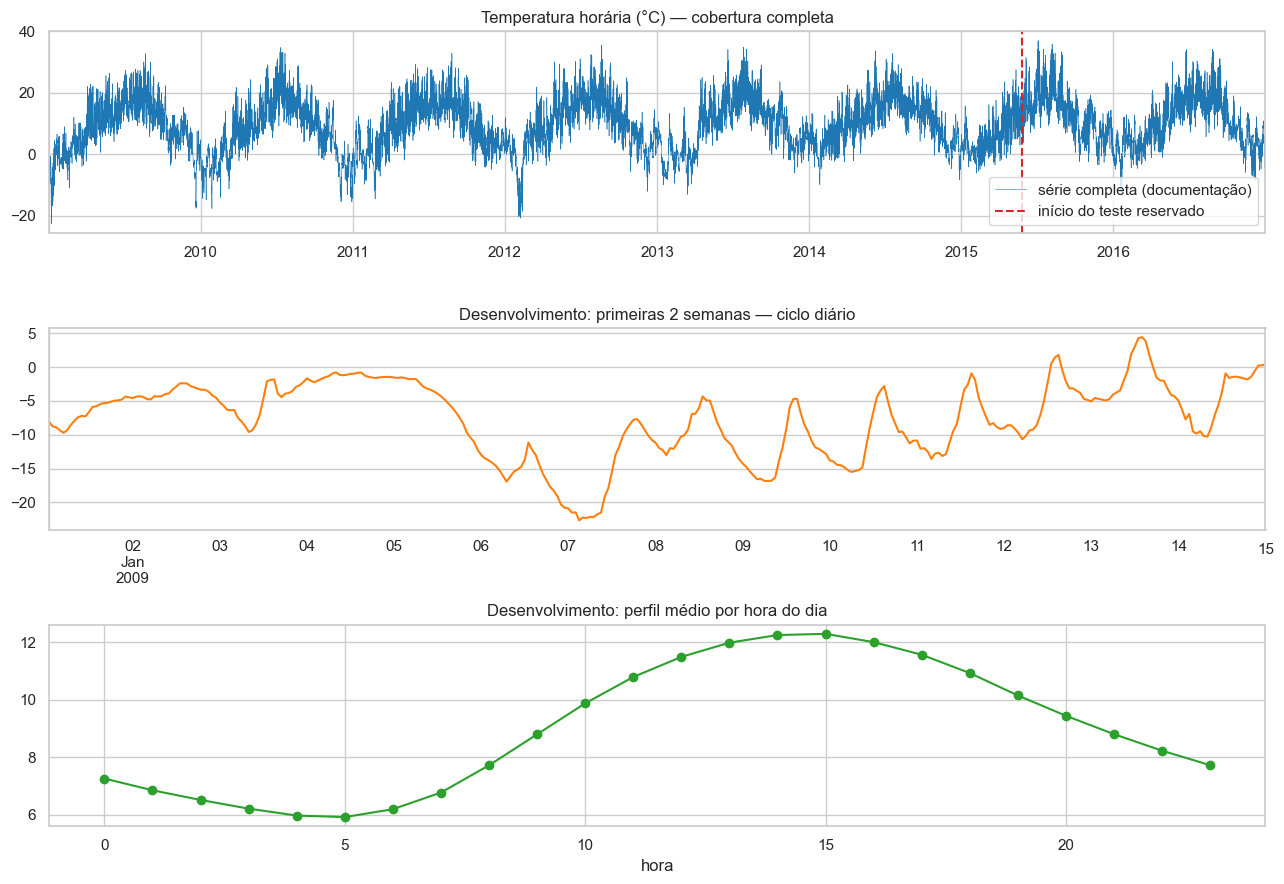

In [3]:
y = hourly[TARGET]
y_dev = dev[TARGET]
fig, axes = plt.subplots(3, 1, figsize=(13, 9))
y.plot(ax=axes[0], lw=.4, color='tab:blue', label='série completa (documentação)')
axes[0].axvline(test.index[0], color='tab:red', ls='--', label='início do teste reservado')
axes[0].set_title('Temperatura horária (°C) — cobertura completa'); axes[0].legend()
y_dev.iloc[:24*14].plot(ax=axes[1], color='tab:orange'); axes[1].set_title('Desenvolvimento: primeiras 2 semanas — ciclo diário')
y_dev.groupby(y_dev.index.hour).mean().plot(ax=axes[2], marker='o', color='tab:green'); axes[2].set_title('Desenvolvimento: perfil médio por hora do dia'); axes[2].set_xlabel('hora')
plt.tight_layout(); plt.show()

Força sazonal (24h) no desenvolvimento: Fs = 0.686 | Força de tendência Ft = 0.953


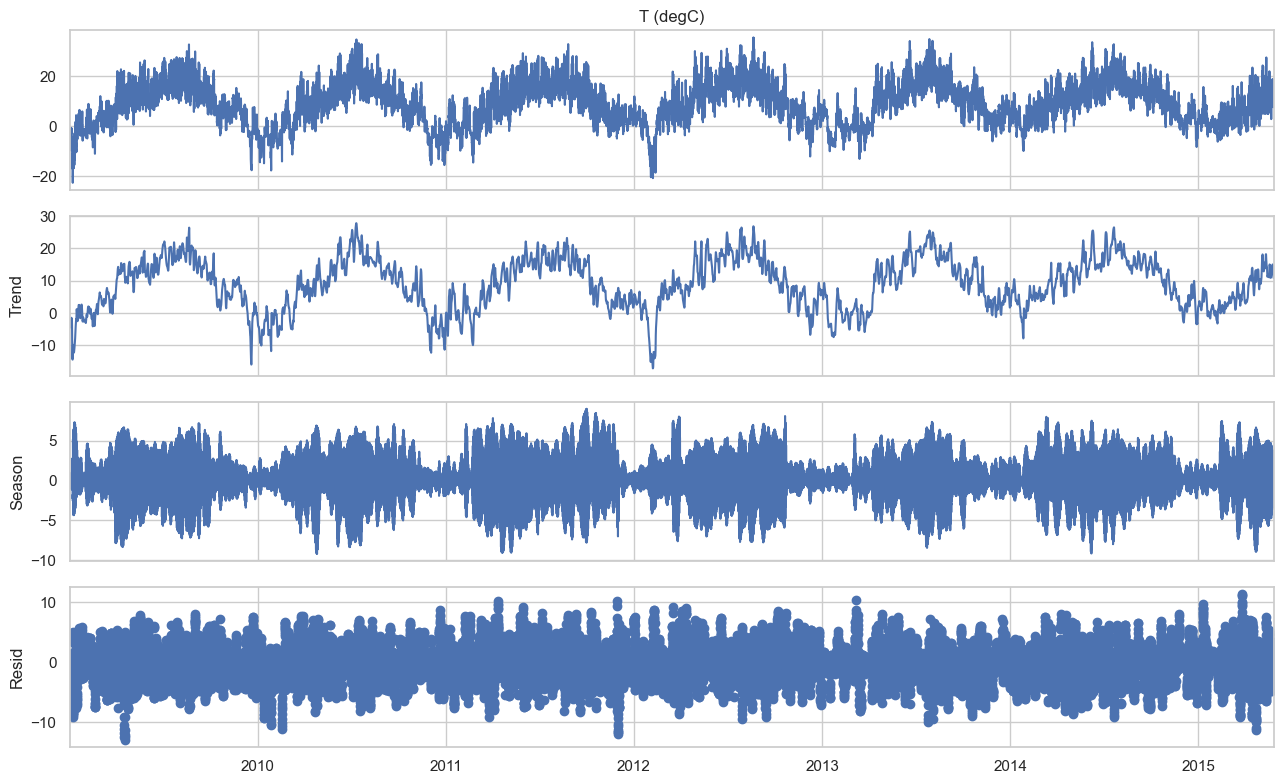

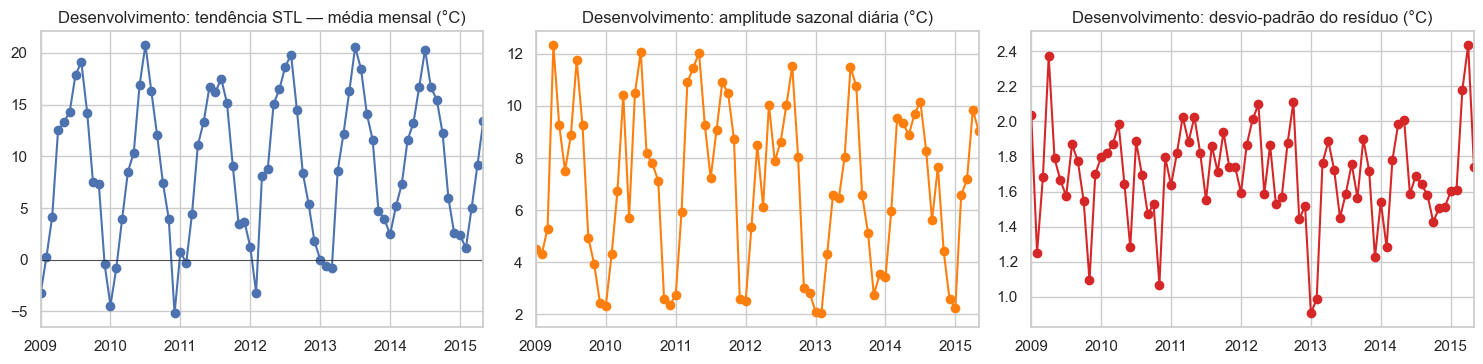

Variação mês a mês da tendência no desenvolvimento (°C):
   2009-02  2009-03  2009-04  2009-05  2009-06  2009-07  2009-08  2009-09  2009-10  2009-11  2009-12  2010-01  2010-02  2010-03  2010-04  2010-05  2010-06  2010-07  2010-08  2010-09  2010-10  2010-11  2010-12  2011-01  2011-02  2011-03  2011-04  2011-05  2011-06  2011-07  2011-08  2011-09  2011-10  2011-11  2011-12  2012-01  2012-02  2012-03  2012-04  2012-05  2012-06  2012-07  2012-08  2012-09  2012-10  2012-11  2012-12  2013-01  2013-02  2013-03  2013-04  2013-05  2013-06  2013-07  2013-08  2013-09  2013-10  2013-11  2013-12  2014-01  2014-02  2014-03  2014-04  2014-05  2014-06  2014-07  2014-08  2014-09  2014-10  2014-11  2014-12  2015-01  2015-02  2015-03  2015-04  2015-05
Δ      3.5      3.9      8.3      0.8      1.0      3.6      1.2     -4.9     -6.8     -0.2     -7.8     -4.0      3.6      4.8      4.6      1.8      6.5      3.9     -4.4     -4.3     -4.6     -3.5     -9.2      6.0     -1.1      4.8      6.6      2.3    

In [4]:
# Decomposição decisória somente nos 80% de desenvolvimento
stl = STL(y_dev, period=SEASONAL_PERIOD, seasonal=7, robust=True).fit()
Fs = max(0, 1 - np.var(stl.resid) / np.var(stl.seasonal + stl.resid))
Ft = max(0, 1 - np.var(stl.resid) / np.var(stl.trend + stl.resid))
print(f'Força sazonal (24h) no desenvolvimento: Fs = {Fs:.3f} | Força de tendência Ft = {Ft:.3f}')
fig = stl.plot(); fig.set_size_inches(13, 8); plt.tight_layout(); plt.show()

trend_m = stl.trend.resample('MS').mean()
amp_d = stl.seasonal.groupby(stl.seasonal.index.date).agg(lambda v: v.max() - v.min())
amp_d.index = pd.to_datetime(amp_d.index)
resid_m = stl.resid.resample('MS').std()
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
trend_m.plot(ax=axes[0], marker='o'); axes[0].set_title('Desenvolvimento: tendência STL — média mensal (°C)'); axes[0].axhline(0, c='k', lw=.5)
amp_d.resample('MS').mean().plot(ax=axes[1], marker='o', color='tab:orange'); axes[1].set_title('Desenvolvimento: amplitude sazonal diária (°C)')
resid_m.plot(ax=axes[2], marker='o', color='tab:red'); axes[2].set_title('Desenvolvimento: desvio-padrão do resíduo (°C)')
plt.tight_layout(); plt.show()
print('Variação mês a mês da tendência no desenvolvimento (°C):')
print(trend_m.diff().round(1).dropna().rename(lambda d: d.strftime('%Y-%m')).to_frame('Δ').T.to_string())
print(f'Resíduo STL: desvio-padrão = {stl.resid.std():.2f} °C | assimetria = {stl.resid.skew():+.2f} | 99% dos |resíduos| < {stl.resid.abs().quantile(.99):.1f} °C')

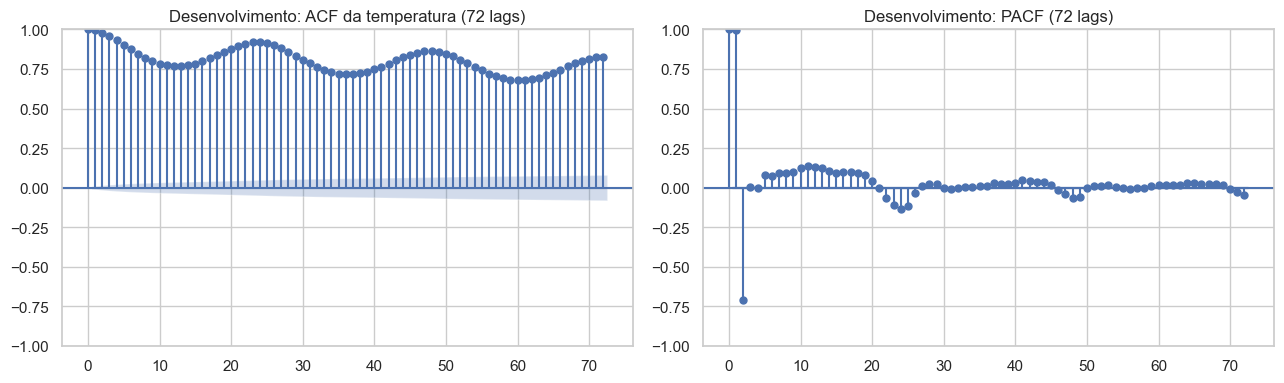

,série,ADF stat,ADF p,KPSS stat,KPSS p
0,nível,-8.1185,0.0,0.4939,0.043
1,diferença 1h,-35.9350,0.0,0.0197,0.100
2,diferença sazonal 24h,-31.8496,0.0,0.0126,0.100


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(y_dev, lags=72, ax=axes[0]); axes[0].set_title('Desenvolvimento: ACF da temperatura (72 lags)')
plot_pacf(y_dev, lags=72, ax=axes[1], method='ywm'); axes[1].set_title('Desenvolvimento: PACF (72 lags)')
plt.tight_layout(); plt.show()

def stationarity_report(series, name):
    adf = adfuller(series.dropna(), autolag='AIC')
    kp = kpss(series.dropna(), regression='c', nlags='auto')
    return {'série': name, 'ADF stat': adf[0], 'ADF p': adf[1], 'KPSS stat': kp[0], 'KPSS p': kp[1]}

stat_tbl = pd.DataFrame([
    stationarity_report(y_dev, 'nível'),
    stationarity_report(y_dev.diff(), 'diferença 1h'),
    stationarity_report(y_dev.diff(SEASONAL_PERIOD), 'diferença sazonal 24h'),
]).round(4)
stat_tbl

**Leitura da EDA (somente desenvolvimento).** A série apresenta ciclo diário forte, com picos da ACF em múltiplos de 24, além do ciclo anual absorvido pela "tendência" da STL de período diário. O ADF rejeita raiz unitária em nível, enquanto o KPSS detecta a não estacionariedade lenta associada à sazonalidade anual. A diferença sazonal de 24 h é, portanto, uma candidata natural para o SARIMAX (`D = 1, m = 24`), sem diferenciação regular (`d = 0`). Essas decisões são posteriormente confrontadas com AIC/BIC e MAE de validação, ainda sem acessar o teste. No PLS e no RF, o ciclo diário entra via lags 24/48 e codificação seno/cosseno da hora; o anual, via seno/cosseno do dia do ano.

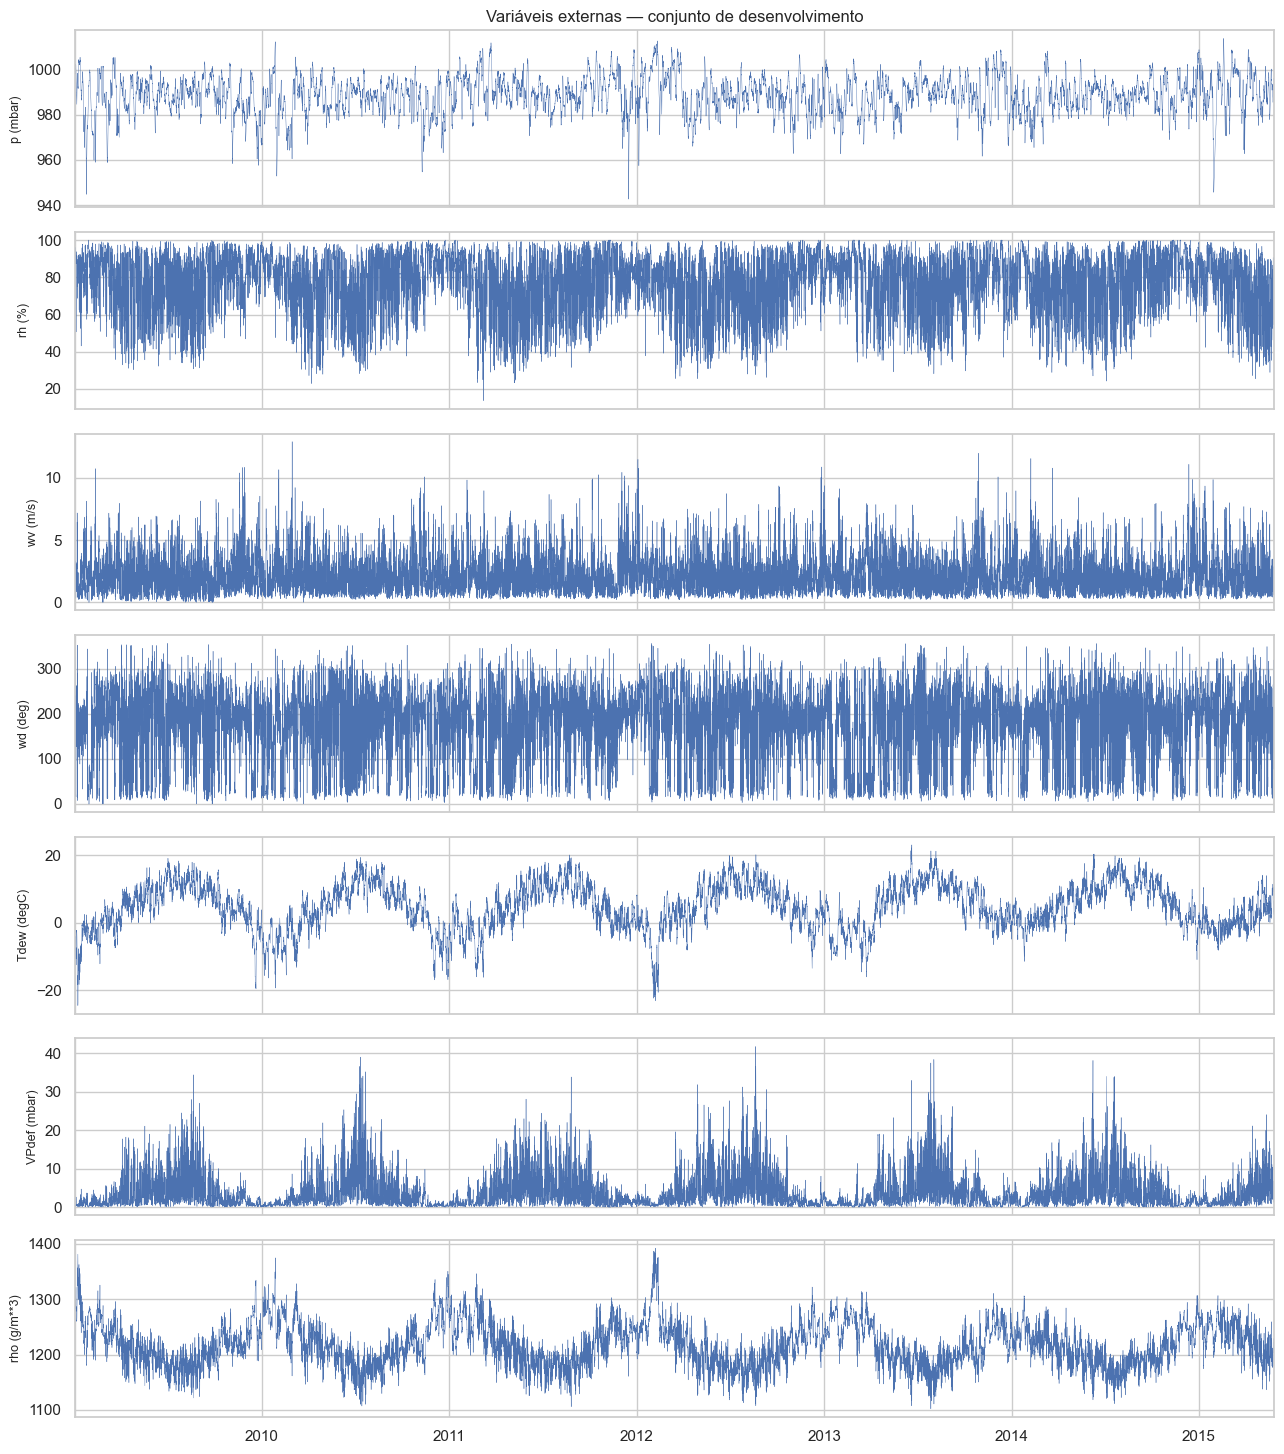

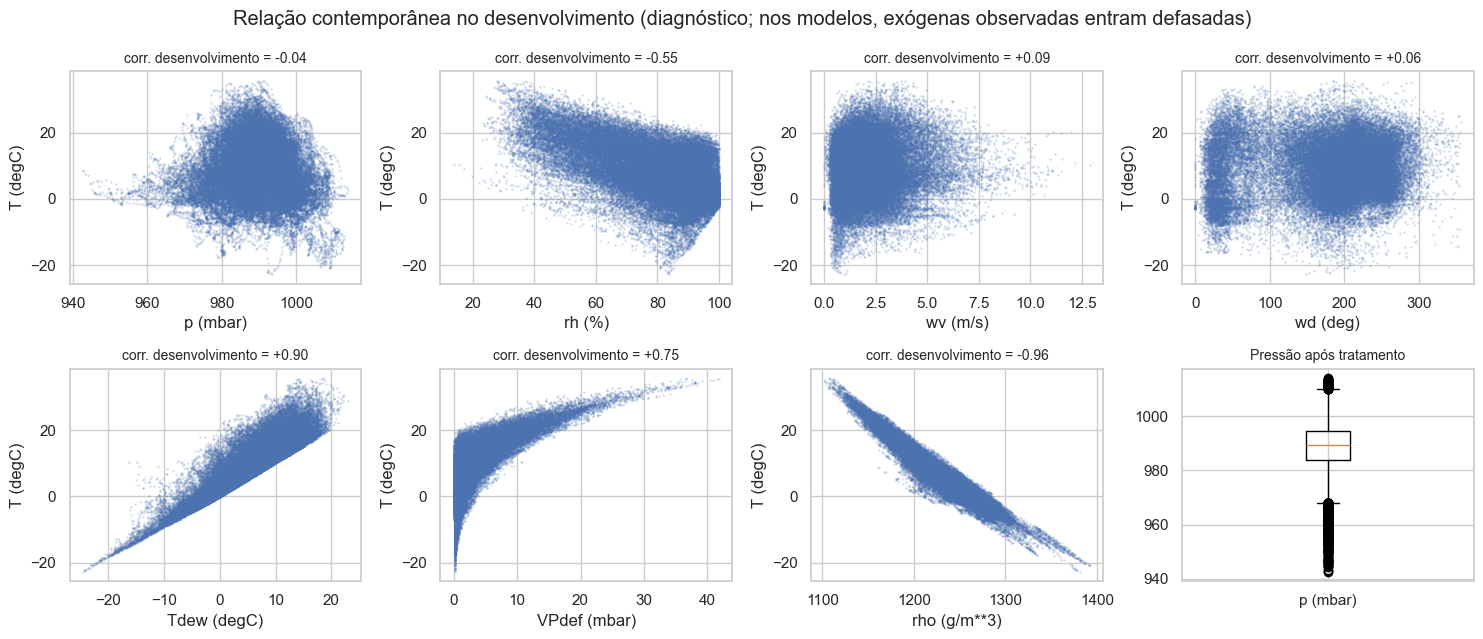

In [6]:
# Principais exógenas no desenvolvimento; o teste continua reservado.
EXOG_PLOT = ['p (mbar)', 'rh (%)', 'wv (m/s)', 'wd (deg)', 'Tdew (degC)', 'VPdef (mbar)', 'rho (g/m**3)']
fig, axes = plt.subplots(len(EXOG_PLOT), 1, figsize=(13, 2.1 * len(EXOG_PLOT)), sharex=True)
for ax, c in zip(axes, EXOG_PLOT):
    dev[c].plot(ax=ax, lw=.3); ax.set_ylabel(c, fontsize=9)
axes[0].set_title('Variáveis externas — conjunto de desenvolvimento'); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, c in zip(axes.ravel(), EXOG_PLOT):
    ax.scatter(dev[c], y_dev, s=1, alpha=.15); ax.set_xlabel(c); ax.set_ylabel('T (degC)')
    ax.set_title(f'corr. desenvolvimento = {dev[c].corr(y_dev):+.2f}', fontsize=10)
axes.ravel()[-1].boxplot([dev['p (mbar)'].dropna()], tick_labels=['p (mbar)']); axes.ravel()[-1].set_title('Pressão após tratamento', fontsize=10)
plt.suptitle('Relação contemporânea no desenvolvimento (diagnóstico; nos modelos, exógenas observadas entram defasadas)')
plt.tight_layout(); plt.show()

**Leitura das exógenas no desenvolvimento.** `rho` é quase uma imagem espelhada de `T`, enquanto `Tdew`, `VPdef` e `rh` apresentam associação física forte com a temperatura. Pressão, velocidade e direção do vento podem ter correlação contemporânea pequena e ainda possuir valor preditivo por suas variações defasadas. Essas relações são diagnósticas, não causais. A relevância fora da amostra será avaliada por coeficientes, VIP e importância por permutação. A pressão não conserva valores do glitch após o tratamento causal.

**Interpretação da decomposição STL (`period = 24`, `robust=True`, somente desenvolvimento).**

*Força dos componentes.* A força sazonal `Fs`, impressa acima, quantifica a importância do ciclo diário por `F = max(0, 1 − Var(R)/Var(S+R))`. A força de tendência `Ft` deve ser interpretada com cuidado: como o período da STL é 24 h, tudo que varia mais lentamente que um dia — ciclo anual e ondas de calor/frio — entra no componente de tendência. Portanto, “tendência” aqui não significa necessariamente deriva monotônica.

*Tendência.* O desenvolvimento contém dois ciclos anuais completos e o início do terceiro. O componente cresce da transição inverno–primavera até o verão e recua no segundo semestre, com mudanças de direção nas transições de estação. Oscilações de vários dias refletem dinâmica sinótica. A ausência de deriva persistente sustenta `d = 0`; essa decisão também é verificada por ADF/KPSS e pela validação temporal.

*Componente sazonal.* O ciclo diário apresenta mínimo próximo ao amanhecer e máximo durante a tarde. Sua amplitude muda com a estação, o que limita uma sazonalidade aditiva fixa. PLS e RF podem representar parte dessa modulação por lags, hora e dia do ano.

*Resíduo.* A dispersão, assimetria e quantil de 99% são calculados acima, sem consultar o teste. Caudas e variação mensal indicam que a STL diária não captura toda a dinâmica meteorológica; isso motiva lags curtos e exógenas defasadas nos modelos preditivos.

## 3. Protocolo de avaliação

* **Split cronológico 80/20**, definido antes da EDA decisória. As primeiras 80% das horas formam desenvolvimento (treino + validação temporal); as 20% finais são o **teste**, não usado na escolha da estrutura nem dos hiperparâmetros.
* **Horizonte** h = 1 hora. Cada hora do teste é um alvo; a origem é a hora anterior. Todos os modelos usam as mesmas origens e o mesmo teste.
* **Walk-forward com atualização observacional e refit periódico**: a cada hora, o valor real recém-observado passa a estar disponível para a próxima origem; os parâmetros são reestimados a cada `REFIT_EVERY = 336 h`. Entre refits, SARIMAX/Holt-Winters atualizam seus estados com parâmetros fixos e PLS/RF usam atributos recalculados com o histórico efetivamente conhecido.
* **Validação temporal**: três blocos de 336 h no final do desenvolvimento, sempre treinando apenas no passado do bloco.
* **Métrica principal**: MAE (°C). Complementares: RMSE, viés, desvio-padrão dos resíduos e MASE com escala ingênua calculada no desenvolvimento.
* **Reprodutibilidade**: `RANDOM_STATE = 42` em todo componente estocástico.

Total: 70127 h (2009-01-01 -> 2016-12-31) | Desenvolvimento: 56101 h (2009-01-01 01:00:00 -> 2015-05-27 13:00:00)
Teste reservado: 14026 h (2015-05-27 14:00:00 -> 2016-12-31 23:00:00) = 20.0%
Blocos de validação temporal (dentro dos 80%):
  treino até 2015-04-15 13:00:00 (55093 h) | validação 2015-04-15 14:00:00 -> 2015-04-29 13:00:00
  treino até 2015-04-29 13:00:00 (55429 h) | validação 2015-04-29 14:00:00 -> 2015-05-13 13:00:00
  treino até 2015-05-13 13:00:00 (55765 h) | validação 2015-05-13 14:00:00 -> 2015-05-27 13:00:00


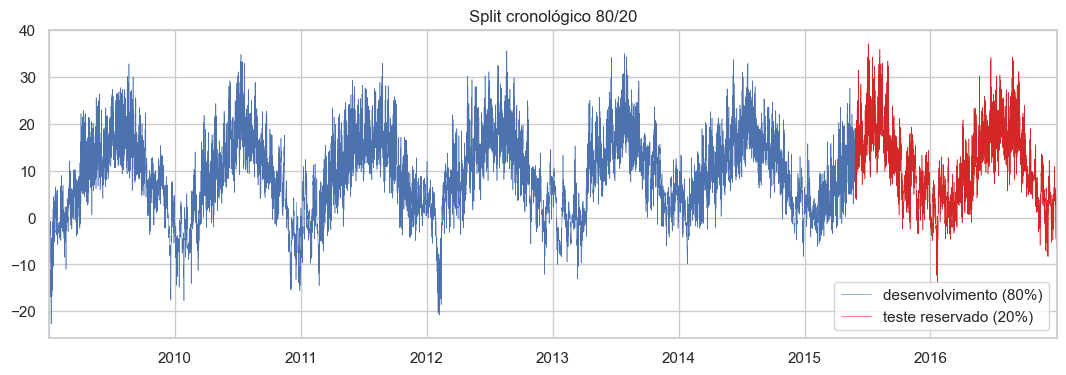

In [7]:
print(f'Total: {n} h ({hourly.index[0].date()} -> {hourly.index[-1].date()}) | Desenvolvimento: {len(dev)} h ({dev.index[0]} -> {dev.index[-1]})')
print(f'Teste reservado: {len(test)} h ({test.index[0]} -> {test.index[-1]}) = {len(test)/n:.1%}')

REFIT_EVERY = 336
N_VAL_FOLDS = 3
VAL_BLOCK = 336
STAT_WINDOW = 1440
HW_WINDOW = 720

def val_folds(dev_index, n_folds=N_VAL_FOLDS, block=VAL_BLOCK):
    folds = []
    end = len(dev_index)
    for k in range(n_folds, 0, -1):
        v_start = end - k * block
        v_end = v_start + block
        folds.append((dev_index[:v_start], dev_index[v_start:v_end]))
    return folds

folds = val_folds(dev.index)
print('Blocos de validação temporal (dentro dos 80%):')
for tr, va in folds:
    print(f'  treino até {tr[-1]} ({len(tr)} h) | validação {va[0]} -> {va[-1]}')

def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))

fig, ax = plt.subplots()
dev[TARGET].plot(ax=ax, lw=.4, label='desenvolvimento (80%)')
test[TARGET].plot(ax=ax, lw=.4, color='tab:red', label='teste reservado (20%)')
ax.legend(); ax.set_title('Split cronológico 80/20'); plt.show()

## 4. Disponibilidade das variáveis externas e engenharia de atributos

### 4.1 Disponibilidade na origem da previsão

Origem = hora `t−1`; alvo = temperatura média da hora `t`. Para cada variável, o que se conhece na origem:

| Variável | Conhecida na origem? | Tratamento adotado |
|---|---|---|
| `T (degC)` (alvo) | passado sim; valor em `t` **não** | lags ≥ 1 h e janelas móveis deslocadas em 1 h |
| `p (mbar)`, `rh (%)`, `wv (m/s)`, `wd (deg)`, `Tdew`, `VPdef`, `rho` | observadas até `t−1`; o valor em `t` **não** (usá-lo seria vazamento: é medido junto com o alvo) | entram **somente defasadas** (`shift(1)`) e como diferenças defasadas (1 h e 24 h) |
| Previsão meteorológica numérica emitida na origem | seria legítima (identificada como previsão), mas **não existe na base** | não utilizada — não há como reconstruir a previsão disponível em cada origem |
| Hora do dia, dia do ano | conhecidas com antecedência (calendário) | codificação cíclica seno/cosseno — as únicas variáveis contemporâneas a `t` |
| Dia da semana, feriados | conhecidos, mas sem efeito físico sobre a temperatura | não utilizados |

Consequências: nenhuma variável observada em `t` entra como atributo. Uma asserção automática abaixo confirma, em amostras aleatórias, que alterar dados a partir de `t` não modifica os atributos da própria hora `t`; janelas móveis e o `StandardScaler` das exógenas do SARIMAX são ajustados apenas com dados anteriores à origem. No SARIMAX usamos um subconjunto de 5 exógenas (`p`, `rh`, `wv`, `wd_sin`, `wd_cos`): `rho`, `Tdew` e `VPdef` são funções quase determinísticas de `T`, `p` e `rh` e, num modelo que já tem termos autorregressivos na própria temperatura, ficariam colineares com a parte ARIMA e encareceriam ainda mais cada refit (~35 s). Nos modelos tabulares (RF e PLS), que lidam bem com redundância, o conjunto completo é usado — e é o **mesmo** para os dois, como exige o roteiro.

### 4.2 Atributos

Para o PLS e o Random Forest, cada linha descreve a hora-alvo `t` apenas com informação disponível em `t-1` (origem):

* **lags da temperatura**: 1, 2, 3, 6, 12, 24, 48 e 168 h;
* **diferenças**: variação na última hora e na última hora em relação a 24 h antes;
* **janelas móveis** da temperatura (média, desvio, mínimo e máximo) em 6, 24 e 168 h, deslocadas em 1;
* **exógenas defasadas em 1 h**: pressão, umidade relativa, velocidade do vento, direção do vento (seno/cosseno), déficit de pressão de vapor, densidade do ar, ponto de orvalho e suas variações em 1 h e 24 h;
* **sazonalidade determinística**: seno/cosseno da hora do dia e do dia do ano.

**Valores ausentes gerados por lags e janelas.** O lag 168 e a janela de 168 h produzem `NaN` nas primeiras 168 horas da série (warm-up). Essas linhas são **descartadas do treino** — não imputadas, porque imputar um passado inexistente introduziria valores artificiais — e nunca coincidem com origens de teste, que começam ~2,4 anos depois do início da série. Nenhum outro `NaN` existe após o tratamento da seção 1.

In [8]:
def build_features(df):
    y = df[TARGET]
    X = pd.DataFrame(index=df.index)
    for L in [1, 2, 3, 6, 12, 24, 48, 168]:
        X[f'T_lag{L}'] = y.shift(L)
    X['T_diff1'] = y.shift(1) - y.shift(2)
    X['T_diff24'] = y.shift(1) - y.shift(25)
    for w in [6, 24, 168]:
        r = y.shift(1).rolling(w)
        X[f'T_rmean{w}'] = r.mean(); X[f'T_rstd{w}'] = r.std()
        X[f'T_rmin{w}'] = r.min(); X[f'T_rmax{w}'] = r.max()
    exog = {'p': df['p (mbar)'], 'rh': df['rh (%)'], 'wv': df['wv (m/s)'],
            'VPdef': df['VPdef (mbar)'], 'rho': df['rho (g/m**3)'], 'Tdew': df['Tdew (degC)']}
    for k, s in exog.items():
        X[f'{k}_lag1'] = s.shift(1)
        X[f'{k}_diff1'] = s.shift(1) - s.shift(2)
        X[f'{k}_diff24'] = s.shift(1) - s.shift(25)
    wd = np.deg2rad(df['wd (deg)'].shift(1))
    X['wd_sin'] = np.sin(wd); X['wd_cos'] = np.cos(wd)
    hod = 2 * np.pi * df.index.hour / 24
    doy = 2 * np.pi * df.index.dayofyear / 365.25
    X['hod_sin'] = np.sin(hod); X['hod_cos'] = np.cos(hod)
    X['doy_sin'] = np.sin(doy); X['doy_cos'] = np.cos(doy)
    return X

X_all = build_features(hourly)
y_all = hourly[TARGET]
valid = X_all.notna().all(axis=1)
print(f'Atributos: {X_all.shape[1]} | linhas válidas (após warm-up de 168 h): {valid.sum()} de {len(X_all)}')
first_valid = X_all.index[valid.values.argmax()]
print('Primeira origem utilizável:', first_valid)

# Auditoria de causalidade: perturbar dados de t em diante não pode mudar X_t.
rng_audit = np.random.default_rng(RANDOM_STATE)
audit_positions = rng_audit.choice(np.arange(200, len(hourly) - 2), size=5, replace=False)
for pos in audit_positions:
    altered = hourly.copy()
    altered.iloc[pos:, :] = altered.iloc[pos:, :] + 1000
    x_before = build_features(hourly.iloc[:pos + 2]).iloc[pos]
    x_after = build_features(altered.iloc[:pos + 2]).iloc[pos]
    if not np.allclose(x_before.values, x_after.values, equal_nan=True):
        raise AssertionError(f'Feature não causal detectada em {hourly.index[pos]}')
print('Auditoria de causalidade das features: aprovada em 5 origens amostradas.')

availability_tbl = pd.DataFrame([
    {'variavel': TARGET, 'disponivel_na_origem': 'passado apenas', 'uso': 'lags e janelas deslocadas'},
    *[{'variavel': c, 'disponivel_na_origem': 'até t-1', 'uso': 'defasagem/diferenças' if c != 'wd (deg)' else 'seno/cosseno defasados'} for c in ['p (mbar)', 'rh (%)', 'wv (m/s)', 'wd (deg)', 'Tdew (degC)', 'VPdef (mbar)', 'rho (g/m**3)']],
    {'variavel': 'hora/dia do ano', 'disponivel_na_origem': 'sim', 'uso': 'seno/cosseno de calendário'},
])
availability_tbl.to_csv(f'{OUT_DIR}/external_availability.csv', index=False)
display(availability_tbl)
list(X_all.columns)

Atributos: 46 | linhas válidas (após warm-up de 168 h): 69959 de 70127
Primeira origem utilizável: 2009-01-08 01:00:00
Auditoria de causalidade das features: aprovada em 5 origens amostradas.


,variavel,disponivel_na_origem,uso
0,T (degC),passado apenas,lags e janelas deslocadas
1,p (mbar),até t-1,defasagem/diferenças
2,rh (%),até t-1,defasagem/diferenças
3,wv (m/s),até t-1,defasagem/diferenças
4,wd (deg),até t-1,seno/cosseno defasados
5,Tdew (degC),até t-1,defasagem/diferenças
6,VPdef (mbar),até t-1,defasagem/diferenças
7,rho (g/m**3),até t-1,defasagem/diferenças
8,hora/dia do ano,sim,seno/cosseno de calendário


['T_lag1',
 'T_lag2',
 'T_lag3',
 'T_lag6',
 'T_lag12',
 'T_lag24',
 'T_lag48',
 'T_lag168',
 'T_diff1',
 'T_diff24',
 'T_rmean6',
 'T_rstd6',
 'T_rmin6',
 'T_rmax6',
 'T_rmean24',
 'T_rstd24',
 'T_rmin24',
 'T_rmax24',
 'T_rmean168',
 'T_rstd168',
 'T_rmin168',
 'T_rmax168',
 'p_lag1',
 'p_diff1',
 'p_diff24',
 'rh_lag1',
 'rh_diff1',
 'rh_diff24',
 'wv_lag1',
 'wv_diff1',
 'wv_diff24',
 'VPdef_lag1',
 'VPdef_diff1',
 'VPdef_diff24',
 'rho_lag1',
 'rho_diff1',
 'rho_diff24',
 'Tdew_lag1',
 'Tdew_diff1',
 'Tdew_diff24',
 'wd_sin',
 'wd_cos',
 'hod_sin',
 'hod_cos',
 'doy_sin',
 'doy_cos']

## 5. Os quatro modelos e a otimização de hiperparâmetros

| Modelo | Família | Usa exógenas? | Espaço de busca investigado | Critério de seleção |
|---|---|---|---|---|
| **Holt-Winters** | suavização exponencial (referência univariada) | não | tendência {nenhuma, aditiva}, amortecimento {sim, não}, sazonalidade {aditiva, nenhuma}, período sazonal {24, 168}; parâmetros de suavização (α, β, γ, φ) estimados por máxima verossimilhança em cada ajuste | MAE 1 passo nos 3 blocos de validação |
| **SARIMAX** | estatístico clássico | sim (defasadas 1 h, padronizadas) | `d = 0`, `D = 1`, `m = 24` fixados pela EDA; `p ∈ {1,2,3}`, `q ∈ {0,1}`, `(P,Q) ∈ {(0,1),(1,1)}`; com/sem exógenas; variante sem componente sazonal | pré-seleção por AIC/BIC → MAE 1 passo nos blocos de validação |
| **Random Forest** | ensemble de árvores | sim (mesmos atributos do PLS) | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` | MAE nos 3 blocos de validação |
| **PLS** (especialização) | regressão linear por variáveis latentes | sim (mesmos atributos do RF) | `n_components` de 1 a 46; conjunto de atributos {só temperatura + calendário, com exógenas} | MAE nos 3 blocos de validação |

Todas as buscas usam **exclusivamente os 80% de desenvolvimento**, com validação temporal por blocos (3 blocos de 336 h no final do desenvolvimento; treino sempre anterior à validação). Os hiperparâmetros escolhidos ficam **congelados** durante o teste.

A sondagem de janelas, feita nos mesmos 3 blocos, mostrou:

| Modelo | Janela testada (h) | MAE médio de validação (°C) | Tempo da sondagem (s) | Decisão |
|---|---:|---:|---:|---|
| Holt-Winters | 720 / 1.440 / 2.160 / 2.880 | 0,551 / 0,561 / 0,571 / 0,577 | 0,4 / 0,9 / 1,5 / 2,2 | **720 h** |
| SARIMAX | 720 / 1.440 / 2.160 / 2.880 | 0,541 / **0,538** / 0,540 / 0,539 | 30 / 59 / 98 / 119 | **1.440 h**: diferença de erro pequena nas alternativas, custo menor |
| Random Forest | 4.380 / 8.760 / 17.520 / crescente | 0,698 / 0,533 / **0,511** / 0,504 | 5,6 / 12,3 / 28,1 / 35,2 | **17.520 h**: quase o melhor, com custo menor que a crescente |
| PLS | 4.380 / 8.760 / 17.520 / crescente | 0,530 / 0,528 / 0,531 / 0,532 | 0,05 / 0,07 / 0,13 / 0,17 | histórico **crescente** |

As escolhas equilibram erro de validação, custo e estabilidade e ficam congeladas no teste. Entre refits, as previsões 1 passo à frente são obtidas filtrando os dados novos com parâmetros congelados (`apply`/filtro), exatamente como o modelo faria em produção.


### 5.1 Holt-Winters (referência univariada)

In [9]:
# ---------- Holt-Winters: busca ----------
# Parâmetros de suavização (alpha, beta, gamma, phi) são estimados por máxima verossimilhança em cada ajuste;
# a busca cobre a estrutura do modelo (tendência, amortecimento, sazonalidade e período sazonal).
def hw_fit(y_train, cfg):
    return ExponentialSmoothing(y_train, trend=cfg['trend'], damped_trend=cfg['damped'] if cfg['trend'] else False,
                                seasonal=cfg['seasonal'], seasonal_periods=cfg.get('sp', SEASONAL_PERIOD),
                                initialization_method='estimated').fit(optimized=True)

def hw_onestep(y_train, y_eval, cfg):
    # ajusta na janela de treino e filtra o período de avaliação com parâmetros congelados
    t0 = time.perf_counter(); res = hw_fit(y_train.iloc[-HW_WINDOW:], cfg); fit_s = time.perf_counter() - t0
    full = pd.concat([y_train.iloc[-HW_WINDOW:], y_eval])
    model_eval = ExponentialSmoothing(full, trend=cfg['trend'], damped_trend=cfg['damped'] if cfg['trend'] else False,
                                      seasonal=cfg['seasonal'], seasonal_periods=cfg.get('sp', SEASONAL_PERIOD),
                                      initialization_method='known',
                                      initial_level=res.params['initial_level'],
                                      initial_trend=res.params.get('initial_trend', None) if cfg['trend'] else None,
                                      initial_seasonal=res.params['initial_seasons'] if cfg['seasonal'] else None)
    fixed = {k: res.params[k] for k in ['smoothing_level', 'smoothing_trend', 'smoothing_seasonal', 'damping_trend'] if k in res.params and not np.isnan(res.params[k])}
    if not cfg['trend']:
        fixed.pop('smoothing_trend', None); fixed.pop('damping_trend', None)
    if not cfg.get('damped', False):
        fixed.pop('damping_trend', None)
    with model_eval.fix_params(fixed):
        r2 = model_eval.fit(optimized=False)
    return r2.fittedvalues.loc[y_eval.index], fit_s, res

hw_grid = [
    {'trend': None,  'damped': False, 'seasonal': 'add', 'sp': 24},
    {'trend': 'add', 'damped': False, 'seasonal': 'add', 'sp': 24},
    {'trend': 'add', 'damped': True,  'seasonal': 'add', 'sp': 24},
    {'trend': 'add', 'damped': True,  'seasonal': 'add', 'sp': 168},   # período semanal: há ciclo além do diário?
    {'trend': None,  'damped': False, 'seasonal': None,  'sp': 24},
    {'trend': 'add', 'damped': True,  'seasonal': None,  'sp': 24},
]
hw_search = []
for cfg in hw_grid:
    fold_maes = []; t0 = time.perf_counter()
    for tr, va in folds:
        pred, _, _ = hw_onestep(y_all.loc[tr], y_all.loc[va], cfg)
        fold_maes.append(mae(y_all.loc[va], pred))
    hw_search.append({**cfg, 'mae_val_mean': np.mean(fold_maes), 'mae_val_std': np.std(fold_maes), 'fit_time_s': time.perf_counter() - t0})
hw_search = pd.DataFrame(hw_search).sort_values('mae_val_mean').reset_index(drop=True)
HW_CFG = {k: hw_search.iloc[0][k] for k in ['trend', 'damped', 'seasonal', 'sp']}
HW_CFG = {k: (None if (isinstance(v, float) and np.isnan(v)) else v) for k, v in HW_CFG.items()}
HW_CFG['damped'] = bool(HW_CFG['damped']); HW_CFG['sp'] = int(HW_CFG['sp'])
print('Holt-Winters selecionado:', HW_CFG)
hw_search.round(4)


Holt-Winters selecionado: {'trend': 'add', 'damped': True, 'seasonal': 'add', 'sp': 24}


,trend,damped,seasonal,sp,mae_val_mean,mae_val_std,fit_time_s
0,add,True,add,24,0.4909,0.0152,1.1418
1,add,False,add,24,0.5336,0.0126,0.7483
2,add,True,None,24,0.5461,0.0398,0.1224
3,None,False,add,24,0.5514,0.0141,0.2675
4,add,True,add,168,0.5669,0.0295,1.6090
5,None,False,None,24,0.9169,0.0621,0.0301


### 5.2 SARIMAX com variáveis exógenas

In [10]:
# ---------- SARIMAX: busca ----------
# d = 0 (ADF rejeita raiz unitária em nível), D = 1 com m = 24 (ciclo diário dominante na STL/ACF).
# Buscamos p, q, P, Q e o uso de exógenas. Exógenas defasadas em 1 h e padronizadas com escala ajustada só no desenvolvimento.
EXOG_COLS = ['p_lag1', 'rh_lag1', 'wv_lag1', 'wd_sin', 'wd_cos']

def scale_exog(train_idx, target_idx):
    scaler = StandardScaler().fit(X_all.loc[train_idx, EXOG_COLS])
    return pd.DataFrame(scaler.transform(X_all.loc[target_idx, EXOG_COLS]), index=target_idx, columns=EXOG_COLS)

def sarimax_onestep(y_train, y_eval, order, sorder, use_exog):
    ytr = y_train.iloc[-STAT_WINDOW:]
    full_y = pd.concat([ytr, y_eval])
    full_x = scale_exog(ytr.index, full_y.index) if use_exog else None
    xtr = full_x.loc[ytr.index] if use_exog else None
    t0 = time.perf_counter(); res = SARIMAX(ytr, exog=xtr, order=order, seasonal_order=sorder).fit(disp=False, maxiter=300); fit_s = time.perf_counter() - t0
    res_ext = res.apply(full_y, exog=full_x)                  # parâmetros congelados, filtro nos dados novos
    pred = res_ext.get_prediction(start=y_eval.index[0], end=y_eval.index[-1]).predicted_mean
    return pred, res, fit_s

sarimax_grid = []
for (p, q) in [(1, 0), (1, 1), (2, 0), (2, 1), (3, 0)]:
    for (P, Q) in [(0, 1), (1, 1)]:
        sarimax_grid.append({'order': (p, 0, q), 'seasonal_order': (P, 1, Q, SEASONAL_PERIOD), 'use_exog': True})
# Etapa 1: pré-seleção por AIC na última janela de treino (barato: um ajuste por candidato)
aic_train = y_all.loc[folds[0][0]].iloc[-STAT_WINDOW:]
aic_exog = scale_exog(aic_train.index, aic_train.index)
aic_rows = []
for cand in sarimax_grid:
    t0 = time.perf_counter()
    r = SARIMAX(aic_train, exog=aic_exog, order=cand['order'], seasonal_order=cand['seasonal_order']).fit(disp=False, maxiter=300)
    aic_rows.append({**cand, 'aic': r.aic, 'bic': r.bic, 'fit_time_s': time.perf_counter() - t0})
aic_tbl = pd.DataFrame(aic_rows).sort_values('aic').reset_index(drop=True)
print('Pré-seleção por AIC/BIC (todos com a mesma diferenciação, logo comparáveis):'); display(aic_tbl.round(2))

# Etapa 2: top-3 por AIC (com exógenas) + melhor sem exógenas + variante sem sazonalidade -> MAE 1 passo nos blocos de validação
finalists = [dict(r) for _, r in aic_tbl.head(3)[['order', 'seasonal_order', 'use_exog']].iterrows()]
finalists.append({**finalists[0], 'use_exog': False})                                                   # mesma ordem, sem exógenas
finalists.append({'order': finalists[0]['order'], 'seasonal_order': (0, 0, 0, 0), 'use_exog': True})   # sem componente sazonal
sarimax_search = []
for cand in finalists:
    fold_maes = []; t0 = time.perf_counter()
    for tr, va in folds:
        pred, _, _ = sarimax_onestep(y_all.loc[tr], y_all.loc[va], cand['order'], cand['seasonal_order'], cand['use_exog'])
        fold_maes.append(mae(y_all.loc[va], pred))
    sarimax_search.append({**cand, 'mae_val_mean': np.mean(fold_maes), 'mae_val_std': np.std(fold_maes), 'fit_time_s': time.perf_counter() - t0})
sarimax_search = pd.DataFrame(sarimax_search).sort_values('mae_val_mean').reset_index(drop=True)
SARIMAX_CFG = sarimax_search.iloc[0][['order', 'seasonal_order', 'use_exog']].to_dict()
SARIMAX_CFG['use_exog'] = bool(SARIMAX_CFG['use_exog'])
print('SARIMAX selecionado:', SARIMAX_CFG)
sarimax_search.round(4)


Pré-seleção por AIC/BIC (todos com a mesma diferenciação, logo comparáveis):


,order,seasonal_order,use_exog,aic,bic,fit_time_s
0,"(3, 0, 0)","(0, 1, 1, 24)",True,3045.75,3098.31,25.01
1,"(3, 0, 0)","(1, 1, 1, 24)",True,3046.43,3104.25,32.55
2,"(2, 0, 1)","(0, 1, 1, 24)",True,3047.40,3099.95,35.21
3,"(2, 0, 1)","(1, 1, 1, 24)",True,3048.15,3105.96,52.80
4,"(2, 0, 0)","(1, 1, 1, 24)",True,3061.44,3113.99,22.05
5,"(2, 0, 0)","(0, 1, 1, 24)",True,3061.53,3108.83,23.16
6,"(1, 0, 1)","(1, 1, 1, 24)",True,3155.72,3208.28,24.76
7,"(1, 0, 1)","(0, 1, 1, 24)",True,3158.86,3206.16,21.20
8,"(1, 0, 0)","(1, 1, 1, 24)",True,3343.02,3390.32,22.45
9,"(1, 0, 0)","(0, 1, 1, 24)",True,3356.15,3398.19,17.68


SARIMAX selecionado: {'order': (2, 0, 1), 'seasonal_order': (0, 1, 1, 24), 'use_exog': True}


,order,seasonal_order,use_exog,mae_val_mean,mae_val_std,fit_time_s
0,"(2, 0, 1)","(0, 1, 1, 24)",True,0.4565,0.0219,98.5437
1,"(3, 0, 0)","(0, 1, 1, 24)",True,0.4577,0.0205,80.1745
2,"(3, 0, 0)","(1, 1, 1, 24)",True,0.4578,0.0217,107.6006
3,"(3, 0, 0)","(0, 1, 1, 24)",False,0.4660,0.0271,22.7997
4,"(3, 0, 0)","(0, 0, 0, 0)",True,0.5418,0.0452,3.4261


### 5.3 Random Forest

In [11]:
# ---------- Random Forest: busca ----------
RF_COLS = list(X_all.columns)
rf_grid = [
    {'n_estimators': 300, 'max_depth': None, 'max_features': 0.33, 'min_samples_split': 2,  'min_samples_leaf': 1},
    {'n_estimators': 300, 'max_depth': None, 'max_features': 0.5,  'min_samples_split': 2,  'min_samples_leaf': 1},
    {'n_estimators': 300, 'max_depth': None, 'max_features': 0.5,  'min_samples_split': 10, 'min_samples_leaf': 1},
    {'n_estimators': 300, 'max_depth': 20,   'max_features': 0.33, 'min_samples_split': 5,  'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 20,   'max_features': 0.5,  'min_samples_split': 5,  'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 12,   'max_features': 0.5,  'min_samples_split': 10, 'min_samples_leaf': 5},
    {'n_estimators': 500, 'max_depth': None, 'max_features': 0.5,  'min_samples_split': 2,  'min_samples_leaf': 1},
    {'n_estimators': 500, 'max_depth': None, 'max_features': 1.0,  'min_samples_split': 2,  'min_samples_leaf': 1},
    # extensão após o ótimo da primeira rodada cair na borda da grade:
    {'n_estimators': 800, 'max_depth': None, 'max_features': 1.0,  'min_samples_split': 2,  'min_samples_leaf': 1},
    {'n_estimators': 500, 'max_depth': 30,   'max_features': 1.0,  'min_samples_split': 2,  'min_samples_leaf': 1},
    {'n_estimators': 500, 'max_depth': None, 'max_features': 0.8,  'min_samples_split': 2,  'min_samples_leaf': 1},
    {'n_estimators': 500, 'max_depth': None, 'max_features': 1.0,  'min_samples_split': 4,  'min_samples_leaf': 2},
]
RF_TRAIN_WINDOW = 17520   # 2 anos de histórico — sondagem: 0,511 °C, melhor que 1 ano (0,533 °C), sem o custo da janela crescente (0,504 °C)

def make_rf(cfg):
    return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **cfg)

rf_search = []
for cfg in rf_grid:
    fold_maes = []; t0 = time.perf_counter()
    for tr, va in folds:
        tr = tr[valid.loc[tr].values][-RF_TRAIN_WINDOW:]
        m = make_rf(cfg).fit(X_all.loc[tr, RF_COLS], y_all.loc[tr])
        fold_maes.append(mae(y_all.loc[va], m.predict(X_all.loc[va, RF_COLS])))
    rf_search.append({**{k: (str(v) if v is None else v) for k, v in cfg.items()}, 'mae_val_mean': np.mean(fold_maes),
                      'mae_val_std': np.std(fold_maes), 'fit_time_s': time.perf_counter() - t0})
rf_search = pd.DataFrame(rf_search).sort_values('mae_val_mean').reset_index(drop=True)
best_row = rf_search.iloc[0]
RF_CFG = {'n_estimators': int(best_row['n_estimators']), 'max_depth': None if best_row['max_depth'] == 'None' else int(best_row['max_depth']),
          'max_features': float(best_row['max_features']), 'min_samples_split': int(best_row['min_samples_split']), 'min_samples_leaf': int(best_row['min_samples_leaf'])}
print('Random Forest selecionado:', RF_CFG)
rf_search.round(4)


Random Forest selecionado: {'n_estimators': 500, 'max_depth': None, 'max_features': 0.8, 'min_samples_split': 2, 'min_samples_leaf': 1}


,n_estimators,max_depth,max_features,min_samples_split,min_samples_leaf,mae_val_mean,mae_val_std,fit_time_s
0,500,None,0.80,2,1,0.4629,0.0359,271.8222
1,500,30,1.00,2,1,0.4644,0.0372,2532.1659
2,800,None,1.00,2,1,0.4644,0.0369,1020.9915
3,300,20,0.50,5,2,0.4646,0.0392,113.7418
4,500,None,1.00,2,1,0.4646,0.0376,485.8818
5,300,None,0.50,10,1,0.4647,0.0364,106.6216
6,500,None,0.50,2,1,0.4651,0.0399,200.8231
7,500,None,1.00,4,2,0.4654,0.0375,308.9263
8,300,None,0.50,2,1,0.4658,0.0408,129.8274
9,300,20,0.33,5,2,0.4677,0.0412,65.0507


### 5.4 Modelo de especialização — PLS Regression

**Por que PLS aqui.** Os atributos são fortemente colineares (lags consecutivos da temperatura, médias móveis, umidade × ponto de orvalho). Regressão linear ordinária fica instável nesse cenário; o PLS projeta `X` em poucos componentes latentes escolhidos para maximizar a covariância com `y`, atuando como regularização por redução de dimensionalidade. O hiperparâmetro central é o **número de componentes** (`n_components`). Também testamos duas variantes de conjunto de atributos (com e sem exógenas) para medir o ganho das variáveis meteorológicas.

A busca usa **validação temporal por blocos** (3 blocos de 2 semanas no final do desenvolvimento): para cada bloco, o modelo é treinado com todo o histórico anterior e avaliado no bloco.


In [12]:
feature_sets = {
    'T_only': [c for c in X_all.columns if c.startswith('T_') or c.startswith('hod_') or c.startswith('doy_')],
    'T+exog': list(X_all.columns),
}

def make_pls(n_comp):
    return Pipeline([('scaler', StandardScaler()), ('pls', PLSRegression(n_components=n_comp, scale=False))])

pls_search = []
for fs_name, cols in feature_sets.items():
    for n_comp in [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 46]:
        if n_comp > len(cols): continue
        fold_maes = []
        t0 = time.perf_counter()
        for tr, va in folds:
            tr = tr[valid.loc[tr].values]
            m = make_pls(n_comp).fit(X_all.loc[tr, cols], y_all.loc[tr])
            fold_maes.append(mae(y_all.loc[va], m.predict(X_all.loc[va, cols]).ravel()))
        pls_search.append({'feature_set': fs_name, 'n_components': n_comp,
                           'mae_val_mean': np.mean(fold_maes), 'mae_val_std': np.std(fold_maes),
                           **{f'mae_fold{i+1}': v for i, v in enumerate(fold_maes)},
                           'fit_time_s': time.perf_counter() - t0})
pls_search = pd.DataFrame(pls_search).sort_values('mae_val_mean').reset_index(drop=True)
pls_search.to_csv(f'{OUT_DIR}/pls_hyperparameter_search.csv', index=False)
pls_search.head(10).round(4)


,feature_set,n_components,mae_val_mean,mae_val_std,mae_fold1,mae_fold2,mae_fold3,fit_time_s
0,T+exog,40,0.4601,0.0436,0.4709,0.5073,0.4021,4.8039
1,T+exog,35,0.4606,0.0442,0.4715,0.5084,0.4018,4.1232
2,T+exog,30,0.4709,0.0435,0.4818,0.5180,0.4130,3.5365
3,T+exog,25,0.4761,0.0422,0.4905,0.5191,0.4187,3.3380
4,T_only,25,0.4799,0.0412,0.4740,0.5330,0.4325,2.0937
5,T_only,20,0.4817,0.0422,0.4768,0.5357,0.4325,2.0024
6,T+exog,20,0.4832,0.0438,0.5015,0.5253,0.4228,2.7766
7,T_only,15,0.4832,0.0376,0.4800,0.5307,0.4389,1.7979
8,T+exog,12,0.4873,0.0473,0.5177,0.5236,0.4205,1.9322
9,T_only,12,0.4889,0.0400,0.4860,0.5393,0.4414,1.5401


PLS selecionado: n_components = 40 | atributos = T+exog (46) | MAE val = 0.4601


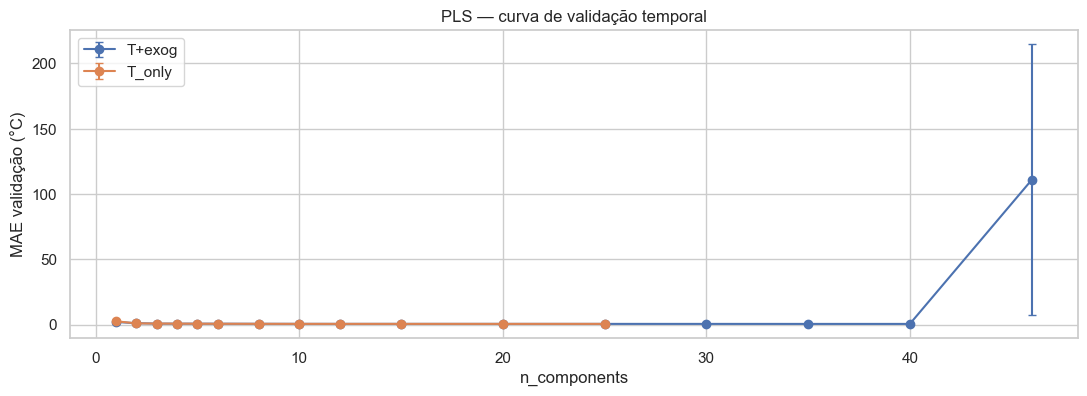

In [13]:
best_pls = pls_search.iloc[0]
PLS_N_COMP = int(best_pls['n_components']); PLS_COLS = feature_sets[best_pls['feature_set']]
print(f"PLS selecionado: n_components = {PLS_N_COMP} | atributos = {best_pls['feature_set']} ({len(PLS_COLS)}) | MAE val = {best_pls['mae_val_mean']:.4f}")

fig, ax = plt.subplots()
for fs_name, g in pls_search.groupby('feature_set'):
    g = g.sort_values('n_components')
    ax.errorbar(g['n_components'], g['mae_val_mean'], yerr=g['mae_val_std'], marker='o', capsize=3, label=fs_name)
ax.set_xlabel('n_components'); ax.set_ylabel('MAE validação (°C)'); ax.set_title('PLS — curva de validação temporal'); ax.legend(); plt.show()


### 5.5 Hiperparâmetros selecionados (congelados para o teste)

In [14]:
selected = pd.DataFrame([
    {'model': 'PLS (especialização)', 'hyperparameters': json.dumps({'n_components': PLS_N_COMP, 'feature_set': best_pls['feature_set'], 'n_features': len(PLS_COLS), 'scaler': 'StandardScaler'}), 'mae_val': best_pls['mae_val_mean']},
    {'model': 'Holt-Winters', 'hyperparameters': json.dumps({**HW_CFG, 'window_h': HW_WINDOW}), 'mae_val': hw_search.iloc[0]['mae_val_mean']},
    {'model': 'SARIMAX', 'hyperparameters': json.dumps({'order': list(SARIMAX_CFG['order']), 'seasonal_order': list(SARIMAX_CFG['seasonal_order']), 'exog': EXOG_COLS if SARIMAX_CFG['use_exog'] else [], 'window_h': STAT_WINDOW}), 'mae_val': sarimax_search.iloc[0]['mae_val_mean']},
    {'model': 'Random Forest', 'hyperparameters': json.dumps({**RF_CFG, 'random_state': RANDOM_STATE, 'train_window_h': RF_TRAIN_WINDOW}), 'mae_val': rf_search.iloc[0]['mae_val_mean']},
])
selected.to_csv(f'{OUT_DIR}/selected_hyperparameters.csv', index=False)
hw_search.to_csv(f'{OUT_DIR}/holtwinters_search.csv', index=False)
sarimax_search.to_csv(f'{OUT_DIR}/sarimax_search.csv', index=False); aic_tbl.to_csv(f'{OUT_DIR}/sarimax_aic_preselection.csv', index=False)
rf_search.to_csv(f'{OUT_DIR}/rf_search.csv', index=False)
selected


,model,hyperparameters,mae_val
0,PLS (especialização),"{""n_components"": 40, ""feature_set"": ""T+exog"", ...",0.460079
1,Holt-Winters,"{""trend"": ""add"", ""damped"": true, ""seasonal"": ""...",0.490898
2,SARIMAX,"{""order"": [2, 0, 1], ""seasonal_order"": [0, 1, ...",0.456462
3,Random Forest,"{""n_estimators"": 500, ""max_depth"": null, ""max_...",0.462892


## 6. Avaliação walk-forward no teste

Todos os modelos percorrem os mesmos blocos de 336 h do teste. Em cada bloco, o modelo é reajustado usando somente dados anteriores à primeira origem. Dentro do bloco, cada previsão continua sendo de **um passo à frente**: para prever a hora `t`, os atributos podem usar o valor real até `t−1`, que já estaria disponível em operação. Os modelos estatísticos filtram as novas observações com parâmetros congelados; PLS e RF recalculam lags/janelas sem refazer parâmetros até o bloco seguinte.

Esse protocolo é um walk-forward com atualização a cada origem e refit periódico, prática necessária para controlar o custo computacional. O último bloco pode ser menor.

In [15]:
test_idx = test.index
blocks = [test_idx[i:i + REFIT_EVERY] for i in range(0, len(test_idx), REFIT_EVERY)]
print(f'{len(blocks)} blocos de refit no teste ({REFIT_EVERY} h cada; último com {len(blocks[-1])} h)')

preds = pd.DataFrame(index=test_idx); preds['y_true'] = y_all.loc[test_idx]
for c in ['PLS', 'Random Forest', 'Holt-Winters', 'SARIMAX']:
    preds[c] = np.nan
runtime = {}
def log_rt(name, fit_s, pred_s):
    runtime.setdefault(name, {'fit_time_s': 0.0, 'predict_time_s': 0.0, 'n_refits': 0})
    runtime[name]['fit_time_s'] += fit_s
    runtime[name]['predict_time_s'] += pred_s
    runtime[name]['n_refits'] += 1

# referências ingênuas
t0 = time.perf_counter(); preds['Persistência'] = y_all.shift(1).loc[test_idx]; log_rt('Persistência', 0.0, time.perf_counter() - t0)
t0 = time.perf_counter(); preds['Sazonal ingênuo (24h)'] = y_all.shift(24).loc[test_idx]; log_rt('Sazonal ingênuo (24h)', 0.0, time.perf_counter() - t0)

# PLS e RF: mesmos atributos e mesmas origens. A permutação do RF é acumulada em todos os blocos.
pls_models = []
rf_importance = np.zeros(len(RF_COLS))
rf_perm_acc = np.zeros(len(RF_COLS))
rf_perm_time_s = 0.0
for b in blocks:
    hist = y_all.index[y_all.index < b[0]]
    hist = hist[valid.loc[hist].values]
    t0 = time.perf_counter(); m = make_pls(PLS_N_COMP).fit(X_all.loc[hist, PLS_COLS], y_all.loc[hist]); tf = time.perf_counter() - t0
    t0 = time.perf_counter(); preds.loc[b, 'PLS'] = m.predict(X_all.loc[b, PLS_COLS]).ravel(); log_rt('PLS', tf, time.perf_counter() - t0); pls_models.append(m)

    hist_rf = hist[-RF_TRAIN_WINDOW:]
    t0 = time.perf_counter(); rf = make_rf(RF_CFG).fit(X_all.loc[hist_rf, RF_COLS], y_all.loc[hist_rf]); tf = time.perf_counter() - t0
    t0 = time.perf_counter(); preds.loc[b, 'Random Forest'] = rf.predict(X_all.loc[b, RF_COLS]); log_rt('Random Forest', tf, time.perf_counter() - t0)
    rf_importance += rf.feature_importances_ * len(b)

    t0 = time.perf_counter()
    pi_b = permutation_importance(rf, X_all.loc[b, RF_COLS], y_all.loc[b], scoring='neg_mean_absolute_error',
                                  n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
    rf_perm_time_s += time.perf_counter() - t0
    rf_perm_acc += pi_b.importances_mean * len(b)
    del rf

rf_importance = pd.Series(rf_importance / len(test_idx), index=RF_COLS).sort_values(ascending=False)
pi_rf = pd.Series(rf_perm_acc / len(test_idx), index=RF_COLS).sort_values(ascending=False)
print(f'PLS e Random Forest concluídos; permutação do RF nos 16 blocos: {rf_perm_time_s:.0f} s.')

42 blocos de refit no teste (336 h cada; último com 250 h)
PLS e Random Forest concluídos; permutação do RF nos 16 blocos: 2497 s.


In [16]:
# --- Holt-Winters ---
hw_params = []
for b in blocks:
    hist = y_all.loc[:b[0]].iloc[:-1]
    t0 = time.perf_counter(); pred, fit_s, hw_res = hw_onestep(hist, y_all.loc[b], HW_CFG); tt = time.perf_counter() - t0
    preds.loc[b, 'Holt-Winters'] = pred.values; log_rt('Holt-Winters', fit_s, tt - fit_s)
    hw_params.append({'bloco': b[0], **{k: hw_res.params.get(k, np.nan) for k in ['smoothing_level', 'smoothing_trend', 'smoothing_seasonal', 'damping_trend']}})
hw_params = pd.DataFrame(hw_params).set_index('bloco'); hw_params.to_csv(f'{OUT_DIR}/holtwinters_params_by_refit.csv')
print('Holt-Winters concluído.')


Holt-Winters concluído.


In [17]:
# --- SARIMAX (mais custoso: ~20-30 s por refit) ---
sarimax_results = []
for i, b in enumerate(blocks):
    hist = y_all.loc[:b[0]].iloc[:-1]
    t0 = time.perf_counter()
    pred, res, fit_s = sarimax_onestep(hist, y_all.loc[b], SARIMAX_CFG['order'], SARIMAX_CFG['seasonal_order'], SARIMAX_CFG['use_exog'])
    tt = time.perf_counter() - t0
    preds.loc[b, 'SARIMAX'] = pred.values; log_rt('SARIMAX', fit_s, tt - fit_s); sarimax_results.append(res)
    print(f'  bloco {i+1}/{len(blocks)} ok ({tt:.1f} s)', end='\r')
print('\nSARIMAX concluído.')
MODELS = ['SARIMAX', 'Holt-Winters', 'Random Forest', 'PLS']          # os quatro modelos do trabalho
REFS = ['Persistência', 'Sazonal ingênuo (24h)']                       # referências ingênuas
preds.to_csv(f'{OUT_DIR}/test_predictions.csv')
residuals = preds[MODELS + REFS].rsub(preds['y_true'], axis=0); residuals.to_csv(f'{OUT_DIR}/test_residuals.csv')
preds.round(3).head()


  bloco 42/42 ok (180.8 s)s)
SARIMAX concluído.


,y_true,PLS,Random Forest,Holt-Winters,SARIMAX,Persistência,Sazonal ingênuo (24h)
2015-05-27 14:00:00,12.410,12.572,12.370,12.402,12.597,12.132,12.470
2015-05-27 15:00:00,12.183,12.311,12.322,12.185,12.517,12.410,10.972
2015-05-27 16:00:00,12.638,12.207,11.726,11.962,12.010,12.183,13.057
2015-05-27 17:00:00,12.478,12.679,12.612,12.589,12.791,12.638,12.977
2015-05-27 18:00:00,12.178,11.989,12.021,11.612,11.602,12.478,12.237


## 7. Resultados comparativos por MAE

Ranking dos quatro modelos no teste (menor MAE = melhor), vitórias por bloco de refit e posição média — o análogo, dentro de uma base, do que o relatório consolida entre as cinco bases. As referências ingênuas entram só como piso e denominador do MASE.


In [18]:
mae_persist = mae(preds['y_true'], preds['Persistência'])
# Escala canônica do MASE: erro ingênuo de um passo calculado apenas no desenvolvimento.
mase_scale = y_all.loc[dev.index].diff().abs().dropna().mean()

rows = []
for m in MODELS + REFS:
    e = preds['y_true'] - preds[m]
    rows.append({'model': m, 'MAE': e.abs().mean(), 'RMSE': np.sqrt((e**2).mean()), 'bias (média do erro)': e.mean(),
                 'residual_std': e.std(), 'MASE (escala ingênua do treino)': e.abs().mean() / mase_scale,
                 'ganho vs persistência no teste (%)': 100 * (1 - e.abs().mean() / mae_persist)})
comparison = pd.DataFrame(rows)
comparison['tipo'] = np.where(comparison['model'].isin(MODELS), 'modelo', 'referência ingênua')
comparison = comparison.sort_values(['tipo', 'MAE']).reset_index(drop=True)
comparison['posição'] = comparison.groupby('tipo')['MAE'].rank().astype('Int64')
comparison.loc[comparison['tipo'] != 'modelo', 'posição'] = pd.NA
comparison.to_csv(f'{OUT_DIR}/model_comparison_mae.csv', index=False)

# Estabilidade temporal dentro desta base; a consolidação entre bases será feita no relatório do grupo.
block_id = pd.Series(np.repeat(np.arange(len(blocks)), [len(b) for b in blocks]), index=test_idx)
mae_block = pd.DataFrame({m: residuals[m].abs().groupby(block_id).mean() for m in MODELS})
rank_block = mae_block.rank(axis=1)
wins = pd.DataFrame({'vitórias (blocos)': (rank_block == 1).sum().astype(int), 'posição média nos blocos': rank_block.mean(),
                     'MAE mediano por bloco': mae_block.median(), 'MAE no pior bloco': mae_block.max()}).sort_values('posição média nos blocos')
wins.to_csv(f'{OUT_DIR}/wins_by_block.csv')

# Incerteza do quase empate: bootstrap pareado dos 16 blocos, diferença de MAE contra o RF.
rng_boot = np.random.default_rng(RANDOM_STATE)
paired_rows = []
for m in ['PLS', 'SARIMAX', 'Holt-Winters']:
    d = (mae_block[m] - mae_block['Random Forest']).to_numpy()
    boot = rng_boot.choice(d, size=(20000, len(d)), replace=True).mean(axis=1)
    paired_rows.append({'comparação': f'{m} − Random Forest', 'diferença média MAE (°C)': d.mean(),
                        'IC95% bootstrap inferior': np.quantile(boot, .025), 'IC95% bootstrap superior': np.quantile(boot, .975),
                        'blocos em que o modelo supera RF': int((d < 0).sum()), 'total de blocos': len(d)})
paired = pd.DataFrame(paired_rows)
paired.to_csv(f'{OUT_DIR}/paired_block_comparison.csv', index=False)

display(comparison.round(4)); display(wins.round(3)); paired.round(4)

,model,MAE,RMSE,bias (média do erro),residual_std,MASE (escala ingênua do treino),ganho vs persistência no teste (%),tipo,posição
0,PLS,0.3983,0.5723,0.0071,0.5723,0.5902,41.5376,modelo,1
1,SARIMAX,0.4064,0.5835,0.0000,0.5836,0.6022,40.3465,modelo,2
2,Random Forest,0.4114,0.6044,0.0147,0.6042,0.6096,39.6099,modelo,3
3,Holt-Winters,0.4259,0.6188,0.0000,0.6188,0.6311,37.4870,modelo,4
4,Persistência,0.6813,0.9478,-0.0011,0.9478,1.0095,0.0000,referência ingênua,<NA>
5,Sazonal ingênuo (24h),2.5642,3.3603,-0.0220,3.3604,3.7994,-276.3754,referência ingênua,<NA>


,vitórias (blocos),posição média nos blocos,MAE mediano por bloco,MAE no pior bloco
PLS,21,1.762,0.409,0.544
SARIMAX,9,2.286,0.413,0.536
Random Forest,11,2.357,0.417,0.627
Holt-Winters,1,3.595,0.434,0.556


,comparação,diferença média MAE (°C),IC95% bootstrap inferior,IC95% bootstrap superior,blocos em que o modelo supera RF,total de blocos
0,PLS − Random Forest,-0.0129,-0.0240,-0.0036,28,42
1,SARIMAX − Random Forest,-0.0049,-0.0183,0.0068,19,42
2,Holt-Winters − Random Forest,0.0145,0.0008,0.0271,10,42


In [19]:
runtime_tbl = pd.DataFrame(runtime).T
runtime_tbl['total_time_s'] = runtime_tbl['fit_time_s'] + runtime_tbl['predict_time_s']
runtime_tbl['fit_time_per_refit_s'] = runtime_tbl['fit_time_s'] / runtime_tbl['n_refits'].clip(lower=1)
search_time = {'SARIMAX': aic_tbl['fit_time_s'].sum() + sarimax_search['fit_time_s'].sum(), 'Holt-Winters': hw_search['fit_time_s'].sum(),
               'Random Forest': rf_search['fit_time_s'].sum(), 'PLS': pls_search['fit_time_s'].sum()}
runtime_tbl['hyperparam_search_time_s'] = pd.Series(search_time)
runtime_tbl = runtime_tbl.loc[MODELS + REFS].reset_index().rename(columns={'index': 'model'})
runtime_tbl.to_csv(f'{OUT_DIR}/runtime_table.csv', index=False)
runtime_tbl.round(3)


,model,fit_time_s,predict_time_s,n_refits,total_time_s,fit_time_per_refit_s,hyperparam_search_time_s
0,SARIMAX,72740.379,36.938,42.0,72777.317,1731.914,589.413
1,Holt-Winters,10.359,0.465,42.0,10.824,0.247,3.919
2,Random Forest,5561.283,16.862,42.0,5578.145,132.412,5386.374
3,PLS,78.445,1.264,42.0,79.709,1.868,52.164
4,Persistência,0.000,0.006,1.0,0.006,0.000,NaN
5,Sazonal ingênuo (24h),0.000,0.004,1.0,0.004,0.000,NaN


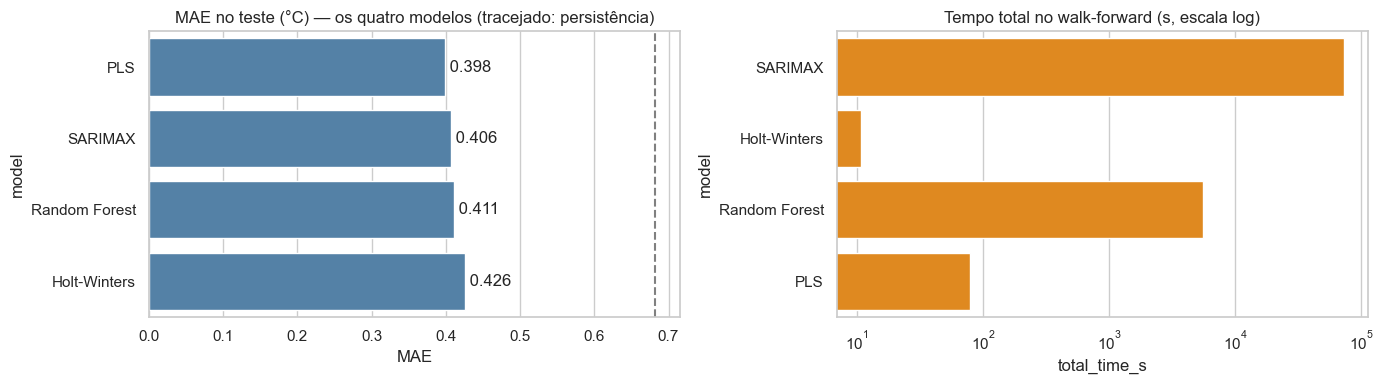

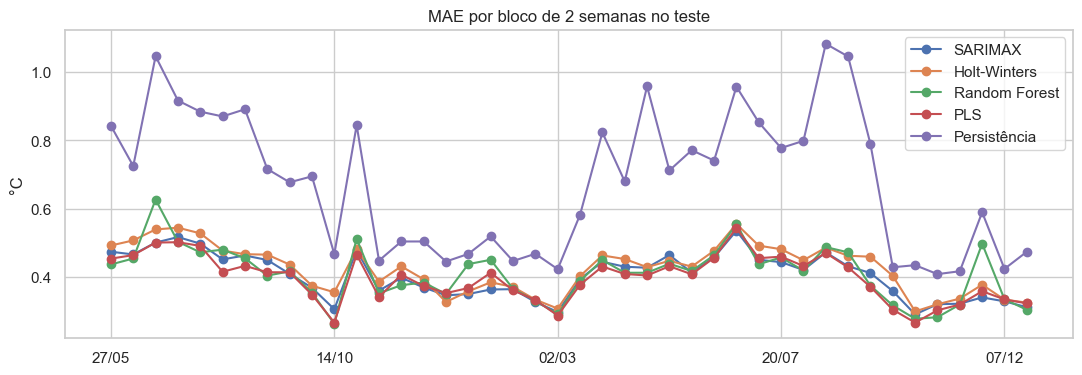

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cmp_plot = comparison[comparison['tipo'] == 'modelo']
sns.barplot(data=cmp_plot, x='MAE', y='model', ax=axes[0], color='steelblue'); axes[0].set_title('MAE no teste (°C) — os quatro modelos (tracejado: persistência)')
for i, v in enumerate(cmp_plot['MAE']): axes[0].text(v, i, f' {v:.3f}', va='center')
axes[0].axvline(mae_persist, ls='--', c='gray')
rt_plot = runtime_tbl[runtime_tbl['model'].isin(MODELS)]
sns.barplot(data=rt_plot, x='total_time_s', y='model', ax=axes[1], color='darkorange'); axes[1].set_xscale('log'); axes[1].set_title('Tempo total no walk-forward (s, escala log)')
plt.tight_layout(); plt.show()

# erro por bloco (estabilidade ao longo do teste)
mb = mae_block.copy(); mb['Persistência'] = residuals['Persistência'].abs().groupby(block_id).mean()
mb.index = [blocks[i][0].strftime('%d/%m') for i in mb.index]
mb.plot(marker='o', figsize=(13, 4), title='MAE por bloco de 2 semanas no teste'); plt.ylabel('°C'); plt.show()


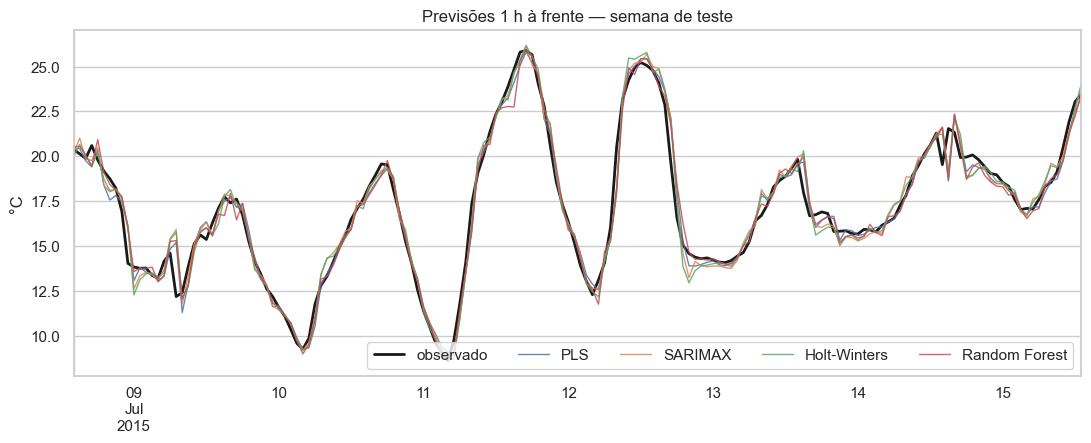

In [21]:
# Zoom visual: uma semana do teste
week = test_idx[24*7*6: 24*7*7]
fig, ax = plt.subplots(figsize=(13, 4.5))
preds.loc[week, 'y_true'].plot(ax=ax, color='k', lw=2, label='observado')
for m, c in zip(['PLS', 'SARIMAX', 'Holt-Winters', 'Random Forest'], ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']):
    preds.loc[week, m].plot(ax=ax, lw=1, alpha=.85, label=m)
ax.legend(ncol=5); ax.set_title('Previsões 1 h à frente — semana de teste'); ax.set_ylabel('°C'); plt.show()


## 8. Análise de resíduos dos quatro modelos

Para cada modelo: série do resíduo no teste, distribuição (média e desvio) e ACF até 48 lags. Um modelo bem especificado deve ter resíduo centrado em zero, sem ciclo diário visível e sem picos na ACF (em especial nos lags 1 e 24). O teste de Ljung-Box formaliza a leitura da ACF.


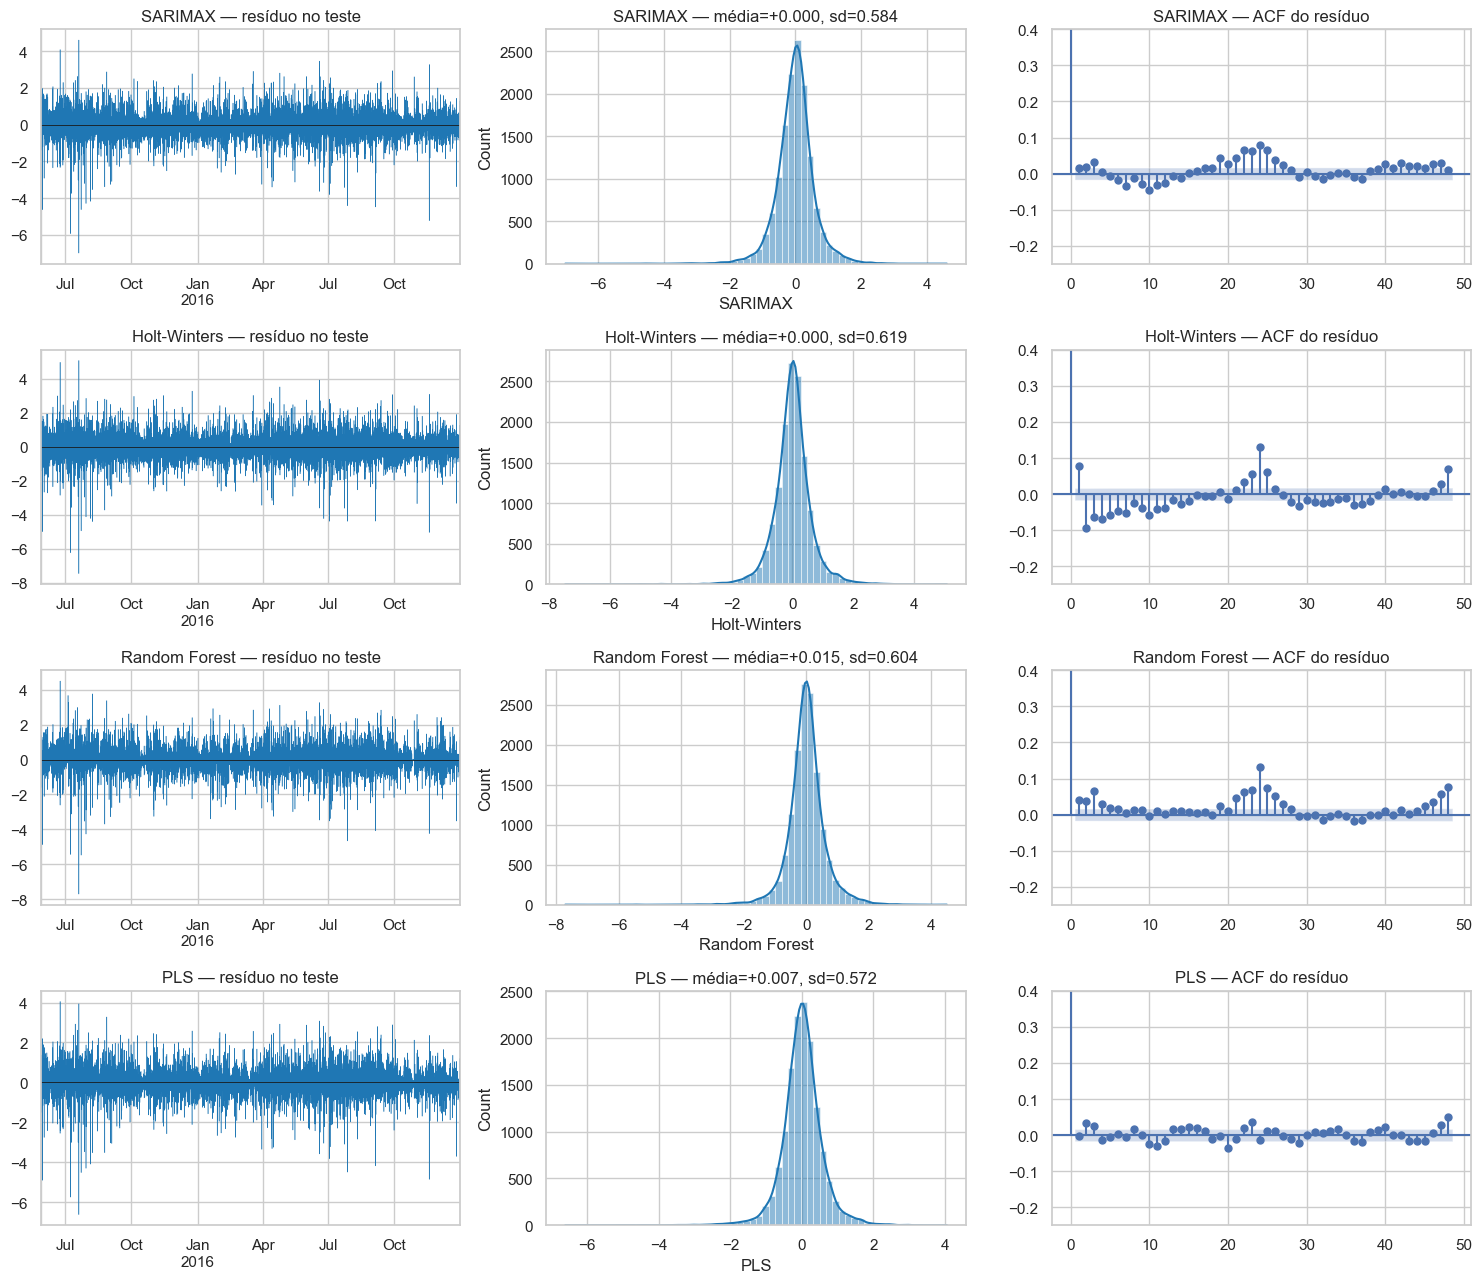

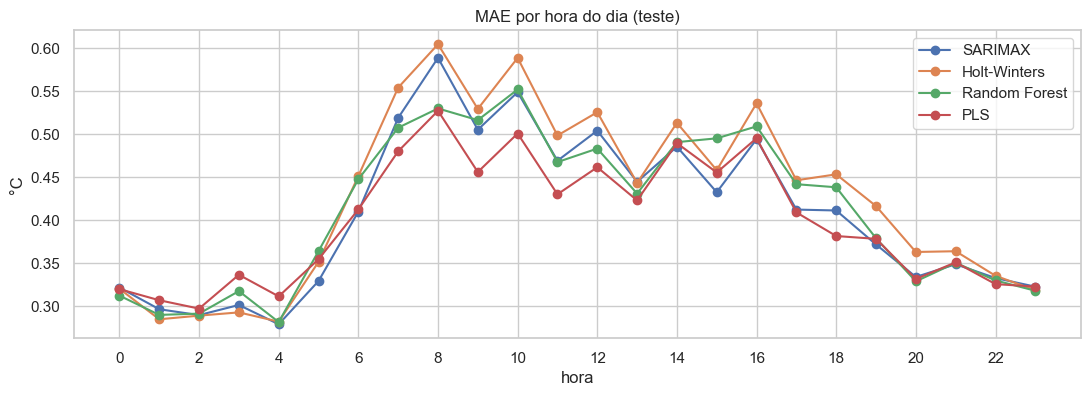

In [22]:
fig, axes = plt.subplots(4, 3, figsize=(15, 13))
for i, m in enumerate(MODELS):
    e = residuals[m]
    e.plot(ax=axes[i, 0], lw=.35, color='tab:blue'); axes[i, 0].axhline(0, c='k', lw=.6); axes[i, 0].set_title(f'{m} — resíduo no teste')
    sns.histplot(e, bins=60, kde=True, ax=axes[i, 1], color='tab:blue'); axes[i, 1].set_title(f'{m} — média={e.mean():+.3f}, sd={e.std():.3f}')
    plot_acf(e.dropna(), lags=48, ax=axes[i, 2]); axes[i, 2].set_title(f'{m} — ACF do resíduo'); axes[i, 2].set_ylim(-0.25, 0.4)
plt.tight_layout(); plt.show()

# erro absoluto médio por hora do dia — mostra se algum modelo falha em horários específicos (ex.: nascer do sol)
by_hour = pd.DataFrame({m: residuals[m].abs().groupby(residuals.index.hour).mean() for m in MODELS})
by_hour.plot(marker='o', figsize=(13, 4), title='MAE por hora do dia (teste)'); plt.xlabel('hora'); plt.ylabel('°C'); plt.xticks(range(0, 24, 2)); plt.show()


In [23]:
# Ljung-Box: H0 = resíduos não autocorrelacionados. p pequeno => sobrou estrutura temporal não capturada.
lb_rows = []
for m in MODELS + REFS:
    e = residuals[m].dropna()
    lb = acorr_ljungbox(e, lags=[24, 48], return_df=True)
    lb_rows.append({'model': m, 'LB_stat_lag24': lb.loc[24, 'lb_stat'], 'LB_p_lag24': lb.loc[24, 'lb_pvalue'],
                    'LB_stat_lag48': lb.loc[48, 'lb_stat'], 'LB_p_lag48': lb.loc[48, 'lb_pvalue'],
                    'acf_lag1': acf(e, nlags=1)[1], 'acf_lag24': acf(e, nlags=24)[24]})
ljung = pd.DataFrame(lb_rows)
ljung.to_csv(f'{OUT_DIR}/ljung_box_comparison.csv', index=False)
ljung.round(4)


,model,LB_stat_lag24,LB_p_lag24,LB_stat_lag48,LB_p_lag48,acf_lag1,acf_lag24
0,SARIMAX,385.4382,0.0,553.9103,0.0,0.0157,0.0788
1,Holt-Winters,897.9475,0.0,1123.9094,0.0,0.0768,0.1316
2,Random Forest,537.2231,0.0,837.8240,0.0,0.0414,0.1323
3,PLS,127.3274,0.0,228.8757,0.0,-0.0027,-0.0129
4,Persistência,47112.5386,0.0,84117.5463,0.0,0.7102,0.5862
5,Sazonal ingênuo (24h),76513.2022,0.0,82723.1775,0.0,0.9672,-0.1444


**Leitura.** Com mais de cinco mil horas de teste, o Ljung-Box pode rejeitar H0 mesmo para autocorrelações pequenas; por isso, p-valor e magnitude da ACF devem ser lidos juntos. Valores de `acf_lag1` e `acf_lag24` próximos de zero indicam que grande parte da dinâmica de curto prazo e do ciclo diário foi absorvida. Rejeitar H0 significa que ainda existe estrutura temporal detectável — não que as previsões sejam necessariamente ruins.

## 9. Importância de atributos e interpretação por modelo

Cada modelo é interpretado pelo método compatível com sua natureza:

| Modelo | Método |
|---|---|
| Holt-Winters | nível, tendência, sazonalidade e parâmetros de suavização |
| SARIMAX | coeficientes das exógenas, sinal, magnitude, significância e estabilidade nos 16 refits |
| Random Forest | importância por impureza e Permutation Importance agregadas nos mesmos 16 blocos de teste |
| PLS | coeficientes padronizados, VIP e Permutation Importance agregada nos 16 blocos |

A permutação é aplicada apenas após a seleção dos modelos e serve para interpretação fora da amostra; não altera hiperparâmetros nem o ranking.

### 9.1 Holt-Winters — nível, tendência e sazonalidade

Parâmetros de suavização estimados por refit (α = nível, β = tendência, γ = sazonalidade, φ = amortecimento):


,smoothing_level,smoothing_trend,smoothing_seasonal,damping_trend
mean,1.0,0.5770,0.0,0.8
min,1.0,0.1786,0.0,0.8
max,1.0,0.9258,0.0,0.8


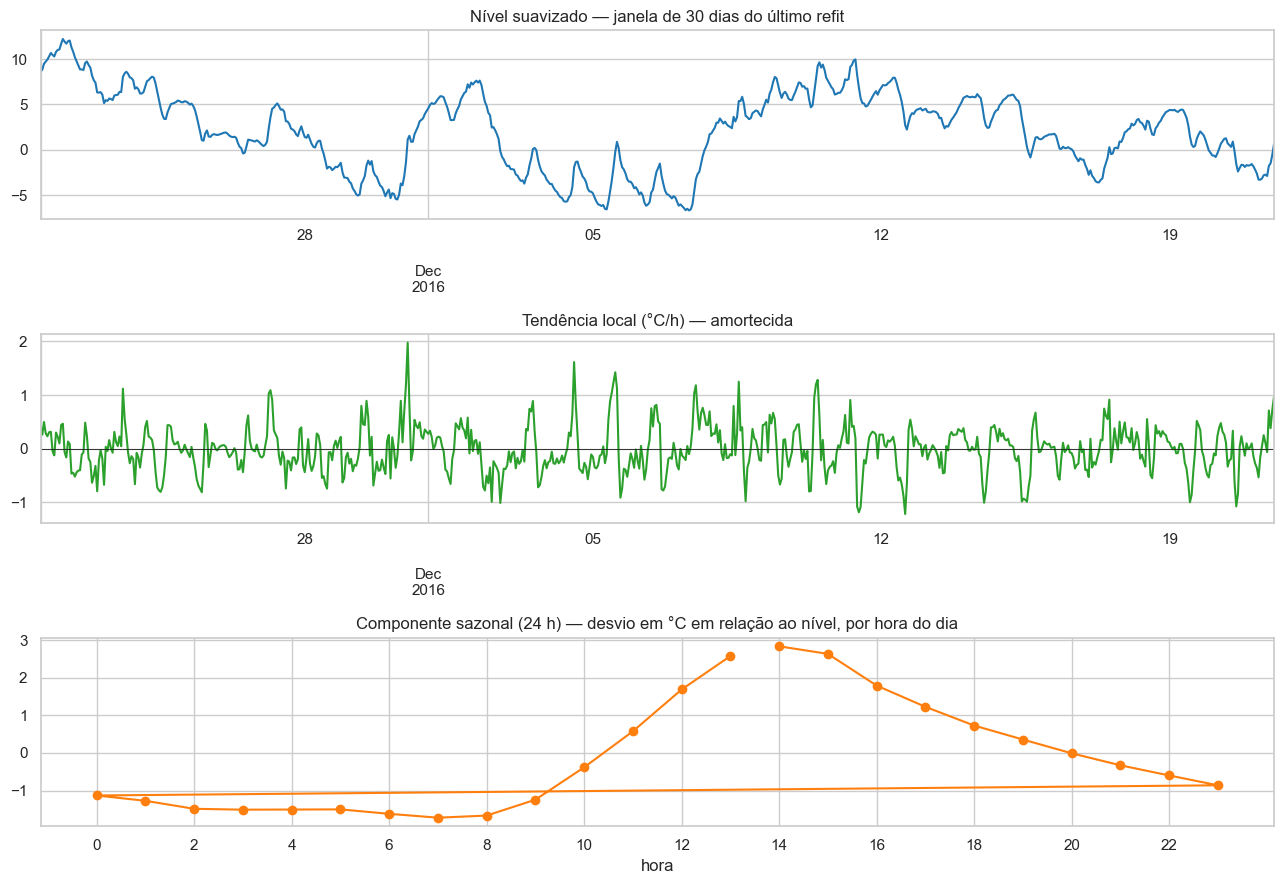

In [24]:
print('Parâmetros de suavização estimados por refit (α = nível, β = tendência, γ = sazonalidade, φ = amortecimento):')
display(hw_params.describe().loc[['mean', 'min', 'max']].round(4))
last_hw = hw_res      # ajuste do último bloco (janela de 30 dias)
fig, axes = plt.subplots(3, 1, figsize=(13, 9))
last_hw.level.plot(ax=axes[0], color='tab:blue'); axes[0].set_title('Nível suavizado — janela de 30 dias do último refit')
if HW_CFG['trend']:
    last_hw.trend.plot(ax=axes[1], color='tab:green'); axes[1].axhline(0, c='k', lw=.6); axes[1].set_title(f"Tendência local (°C/h){' — amortecida' if HW_CFG['damped'] else ''}")
else:
    axes[1].text(0.5, 0.5, 'modelo sem componente de tendência', ha='center', transform=axes[1].transAxes)
if HW_CFG['seasonal']:
    seas = last_hw.season.iloc[-HW_CFG['sp']:]
    axes[2].plot(seas.index.hour, seas.values, marker='o', color='tab:orange'); axes[2].set_xticks(range(0, 24, 2))
    axes[2].set_title(f"Componente sazonal ({HW_CFG['sp']} h) — desvio em °C em relação ao nível, por hora do dia"); axes[2].set_xlabel('hora')
plt.tight_layout(); plt.show()


**Leitura.** A tabela `hw_params` e o gráfico mostram como o Holt-Winters distribui a informação entre nível, tendência, sazonalidade e amortecimento nos 16 refits. Se `smoothing_level` se aproximar de 1, a observação mais recente domina; se `smoothing_seasonal` se aproximar de 0, o perfil diário fica praticamente congelado na janela de ajuste. Essa é uma forma transparente de diagnosticar quando o modelo se aproxima de persistência + perfil sazonal fixo. A janela escolhida foi de 720 h (30 dias), a menor MAE da sondagem. Como não vê exógenas, ele não antecipa diretamente mudanças abruptas associadas a frentes, pressão ou umidade.

### 9.2 SARIMAX — coeficientes das exógenas: sinal, magnitude e significância

Último refit — coeficientes, erros-padrão e significância:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p_lag1        -1.6154      0.260     -6.215      0.000      -2.125      -1.106
rh_lag1        0.5112      0.045     11.475      0.000       0.424       0.599
wv_lag1       -0.0091      0.019     -0.483      0.629      -0.046       0.028
wd_sin        -0.0220      0.011     -2.031      0.042      -0.043      -0.001
wd_cos         0.0075      0.016      0.469      0.639      -0.024       0.039
ar.L1          1.4927      0.029     51.608      0.000       1.436       1.549
ar.L2         -0.5100      0.028    -17.917      0.000      -0.566      -0.454
ma.L1          0.1582      0.037      4.314      0.000       0.086       0.230
ma.S.L24      -0.9480      0.009   -107.951      0.000      -0.965      -0.931
sigma2         0.2114      0.003     61.798      0.000       0.205      

,coef médio,coef mín,coef máx,p-valor mediano,"% refits com p<0,05"
p_lag1,-1.2763,-2.7027,-0.3309,0.0006,78.5714
rh_lag1,0.5996,0.2817,1.2744,0.0000,100.0000
wv_lag1,-0.0444,-0.1032,0.0362,0.0574,47.6190
wd_sin,0.0041,-0.0304,0.0436,0.3773,14.2857
wd_cos,-0.0036,-0.0418,0.0303,0.3720,4.7619
ar.L1,1.4493,1.2682,1.5821,0.0000,100.0000
ar.L2,-0.4712,-0.6055,-0.2963,0.0000,100.0000
ma.L1,0.1415,-0.0817,0.2523,0.0004,78.5714
ma.S.L24,-0.9319,-0.9983,-0.7913,0.0000,100.0000
sigma2,0.3430,0.2032,0.5372,0.0000,100.0000


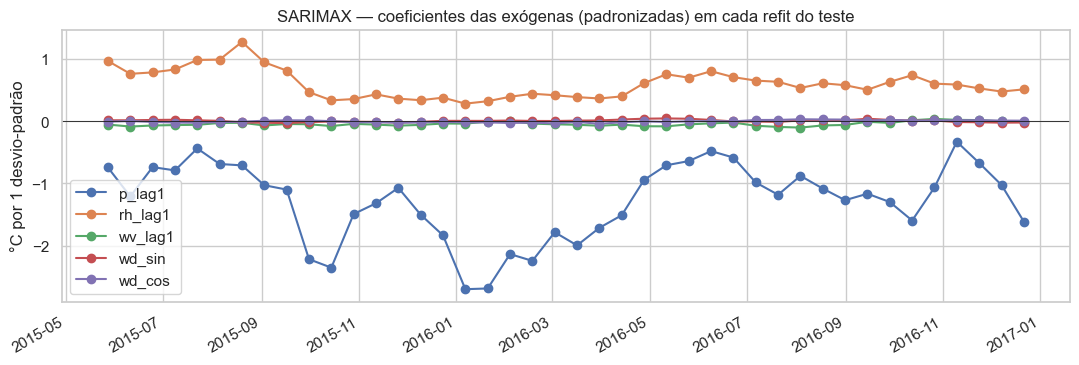

In [25]:
# coeficientes ao longo dos 16 refits (exógenas padronizadas: efeito em °C por 1 desvio-padrão da variável)
coef = pd.DataFrame([r.params for r in sarimax_results], index=[b[0] for b in blocks])
pval = pd.DataFrame([r.pvalues for r in sarimax_results], index=coef.index)
coef_summary = pd.DataFrame({'coef médio': coef.mean(), 'coef mín': coef.min(), 'coef máx': coef.max(),
                             'p-valor mediano': pval.median(), '% refits com p<0,05': 100 * (pval < 0.05).mean()})
coef_summary.to_csv(f'{OUT_DIR}/sarimax_coefficients_by_refit.csv')
print('Último refit — coeficientes, erros-padrão e significância:'); print(sarimax_results[-1].summary().tables[1])
display(coef_summary.round(4))

ex_cols = [c for c in coef.columns if c in EXOG_COLS]
if ex_cols:
    fig, ax = plt.subplots(figsize=(13, 4))
    coef[ex_cols].plot(ax=ax, marker='o'); ax.axhline(0, c='k', lw=.6)
    ax.set_title('SARIMAX — coeficientes das exógenas (padronizadas) em cada refit do teste'); ax.set_ylabel('°C por 1 desvio-padrão'); plt.show()


**Leitura.** Sinal e magnitude devem ser lidos condicionalmente à parte ARIMA: o coeficiente mede o efeito da exógena *além* do que os lags da própria temperatura já explicam. A tabela `coef_summary` mostra, com números calculados nos refits, quais efeitos são estáveis e significativos; não se deve interpretar um coeficiente isolado como causalidade. Pressão e umidade são candidatas fisicamente plausíveis porque antecedem frentes e modulam o resfriamento, enquanto velocidade/direção do vento podem perder significância depois que a dinâmica autorregressiva é controlada. A parte ARIMA e a componente sazonal também devem ser avaliadas pelos sinais, amplitude e p-valores registrados na tabela, sem generalizar os valores de uma execução anterior.

### 9.3 Random Forest — importância nativa e Permutation Importance

Permutation Importance do RF já calculada e agregada nos 42 blocos (2497 s).


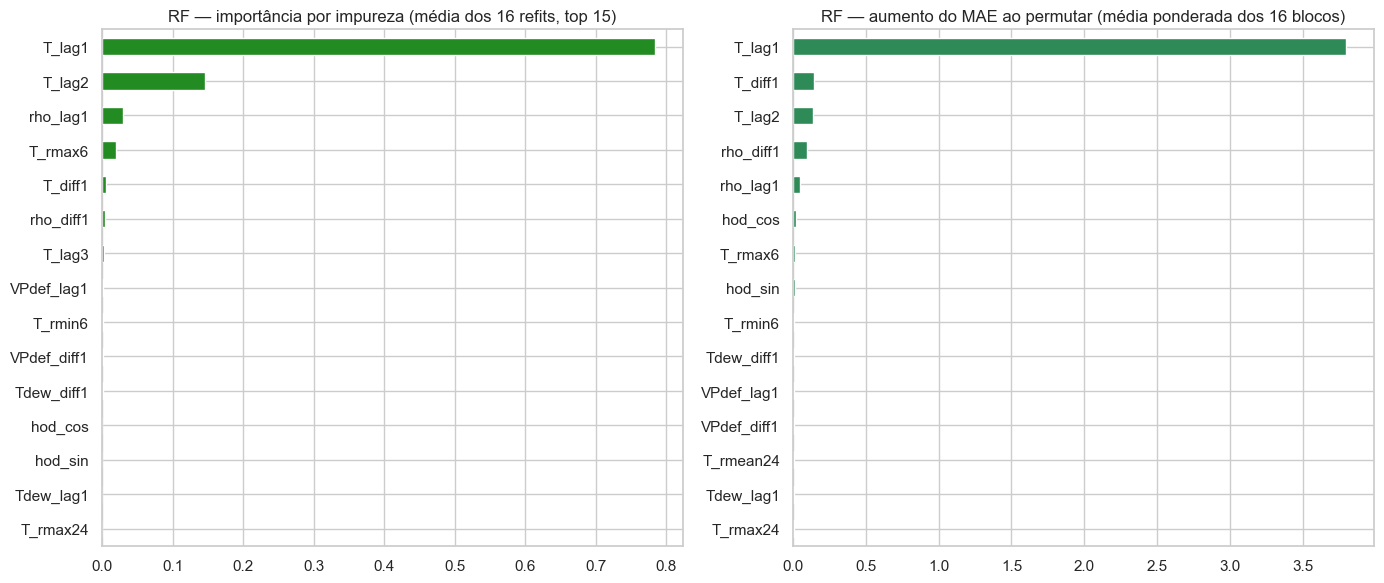

In [26]:
print(f'Permutation Importance do RF já calculada e agregada nos {len(blocks)} blocos ({rf_perm_time_s:.0f} s).')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importance.head(15).iloc[::-1].plot.barh(ax=axes[0], color='forestgreen'); axes[0].set_title('RF — importância por impureza (média dos 16 refits, top 15)')
pi_rf.head(15).iloc[::-1].plot.barh(ax=axes[1], color='seagreen'); axes[1].set_title('RF — aumento do MAE ao permutar (média ponderada dos 16 blocos)')
plt.tight_layout(); plt.show()

**Leitura.** A importância por impureza e a permutação devem ser lidas juntas. A primeira pode favorecer atributos contínuos e correlacionados; a segunda mede a perda efetiva de desempenho fora da amostra, embora distribua importância de forma instável quando várias features carregam informação redundante. Os valores agora são agregados nas mesmas 16 origens de refit utilizadas pelo PLS, tornando a comparação temporalmente homogênea. Importâncias negativas pequenas devem ser interpretadas como ruído de permutação, não como benefício garantido de remover a variável.

### 9.4 PLS — coeficientes, VIP e Permutation Importance

* **Coeficientes padronizados (`coef_`)**: efeito de cada atributo (em desvios-padrão) sobre a previsão. Com atributos colineares, coeficientes individuais grandes e de sinais opostos (ex.: `T_lag1` positivo e `T_rmean6` negativo) são esperados — o modelo combina lags para extrair *tendência local*, não apenas nível.
* **VIP (Variable Importance in Projection)**: importância acumulada de cada variável nos componentes latentes; VIP > 1 é a regra usual de relevância.
* **Importância por permutação no teste** (`random_state = 42`): aumento do MAE ao embaralhar cada variável, calculado bloco a bloco com o modelo daquele bloco — mede o que o modelo realmente *usa* para prever fora da amostra.


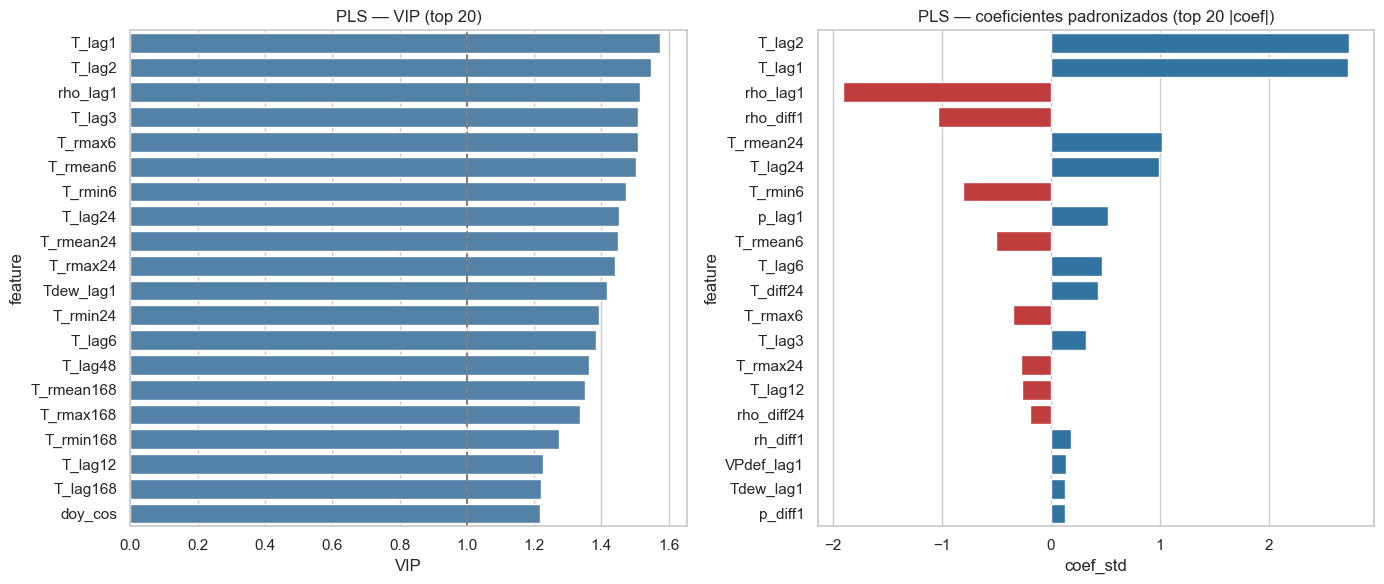

,feature,coef_std,VIP
0,T_lag1,2.7228,1.5750
1,T_lag2,2.7325,1.5477
34,rho_lag1,-1.9111,1.5147
2,T_lag3,0.3225,1.5100
13,T_rmax6,-0.3504,1.5094
10,T_rmean6,-0.5061,1.5017
12,T_rmin6,-0.8052,1.4733
5,T_lag24,0.9869,1.4536
14,T_rmean24,1.0201,1.4490
17,T_rmax24,-0.2736,1.4393


In [27]:
def vip_scores(pls, Xs):
    t = pls.transform(Xs); w = pls.x_weights_; q = pls.y_loadings_
    p, h = w.shape
    ss = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    total = ss.sum()
    w_norm = w / np.linalg.norm(w, axis=0, keepdims=True)
    return np.sqrt(p * ((w_norm**2) @ ss).ravel() / total)

final_pipe = pls_models[-1]; final_pls = final_pipe.named_steps['pls']
hist_last = y_all.index[y_all.index < blocks[-1][0]]; hist_last = hist_last[valid.loc[hist_last].values]
Xs_last = final_pipe.named_steps['scaler'].transform(X_all.loc[hist_last, PLS_COLS])
interp = pd.DataFrame({'feature': PLS_COLS, 'coef_std': final_pls.coef_.ravel(),
                       'VIP': vip_scores(final_pls, Xs_last)}).sort_values('VIP', ascending=False)
interp.to_csv(f'{OUT_DIR}/pls_coefficients_vip.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top = interp.head(20)
sns.barplot(data=top, x='VIP', y='feature', ax=axes[0], color='steelblue'); axes[0].axvline(1, ls='--', c='gray'); axes[0].set_title('PLS — VIP (top 20)')
top_c = interp.reindex(interp['coef_std'].abs().sort_values(ascending=False).index).head(20)
sns.barplot(data=top_c, x='coef_std', y='feature', ax=axes[1], palette=['tab:red' if v < 0 else 'tab:blue' for v in top_c['coef_std']]); axes[1].set_title('PLS — coeficientes padronizados (top 20 |coef|)')
plt.tight_layout(); plt.show()
interp.head(15).round(4)


Permutação (PLS) concluída em 75 s


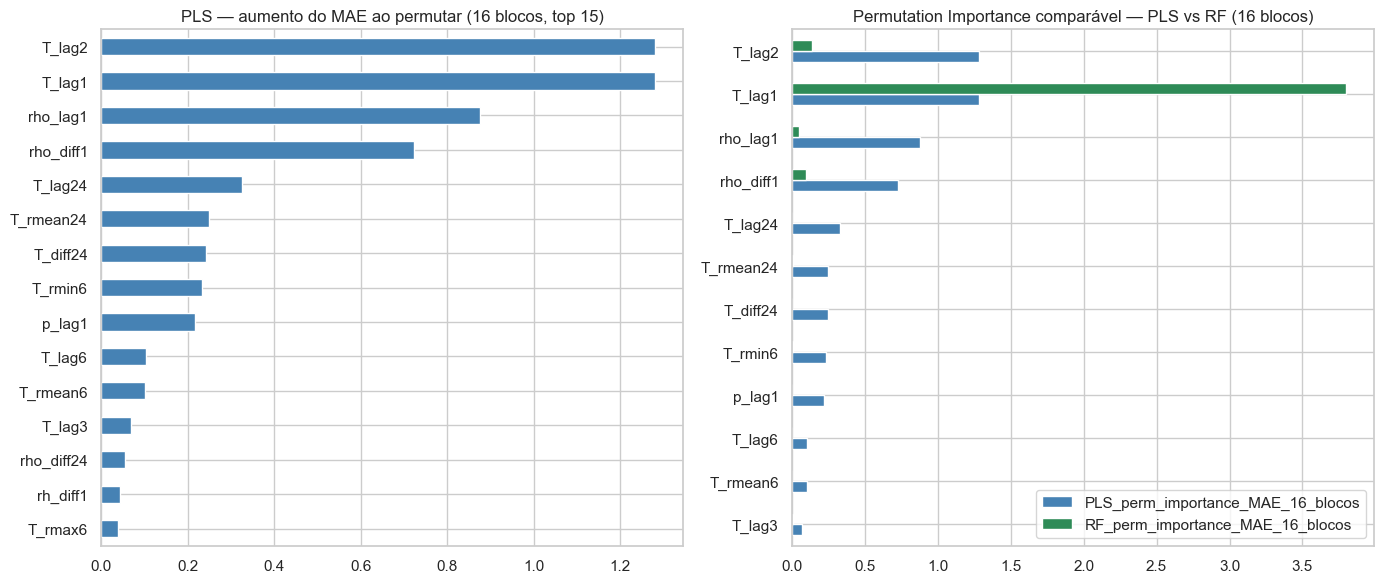

,PLS_perm_importance_MAE_16_blocos,RF_impurity_importance_16_refits,RF_perm_importance_MAE_16_blocos
T_lag2,1.2810,0.1460,0.1380
T_lag1,1.2805,0.7847,3.8008
rho_lag1,0.8770,0.0291,0.0486
rho_diff1,0.7242,0.0034,0.0959
T_lag24,0.3268,0.0002,0.0007
T_rmean24,0.2485,0.0003,0.0037
T_diff24,0.2433,0.0001,0.0001
T_rmin6,0.2336,0.0008,0.0061
p_lag1,0.2179,0.0002,0.0001
T_lag6,0.1029,0.0001,0.0009


In [28]:
# Importância por permutação do PLS, bloco a bloco, com o modelo correspondente.
def block_perm_importance(models, cols, n_repeats=5):
    acc = np.zeros(len(cols))
    for m, b in zip(models, blocks):
        r = permutation_importance(m, X_all.loc[b, cols], y_all.loc[b], scoring='neg_mean_absolute_error',
                                   n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=1)
        acc += r.importances_mean * len(b)
    return pd.Series(acc / len(test_idx), index=cols).sort_values(ascending=False)

t0 = time.perf_counter()
pi_pls = block_perm_importance(pls_models, PLS_COLS)
print(f'Permutação (PLS) concluída em {time.perf_counter()-t0:.0f} s')
pi_tbl = pd.DataFrame({'PLS_perm_importance_MAE_16_blocos': pi_pls,
                       'RF_impurity_importance_16_refits': rf_importance,
                       'RF_perm_importance_MAE_16_blocos': pi_rf}).fillna(0)
pi_tbl.to_csv(f'{OUT_DIR}/feature_importance.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pi_pls.head(15).iloc[::-1].plot.barh(ax=axes[0], color='steelblue'); axes[0].set_title('PLS — aumento do MAE ao permutar (16 blocos, top 15)')
top_features = pi_pls.head(12).index
both = pi_tbl.loc[top_features, ['PLS_perm_importance_MAE_16_blocos', 'RF_perm_importance_MAE_16_blocos']]
both.iloc[::-1].plot.barh(ax=axes[1], color=['steelblue', 'seagreen']); axes[1].set_title('Permutation Importance comparável — PLS vs RF (16 blocos)')
plt.tight_layout(); plt.show()
pi_tbl.sort_values('PLS_perm_importance_MAE_16_blocos', ascending=False).head(12).round(4)

## 10. Explicação aprofundada do modelo de especialização — PLS Regression

### 10.1 Funcionamento e intuição

A regressão linear múltipla (OLS) resolve `min ‖y − Xβ‖²` usando **todas** as direções do espaço de atributos, inclusive as de variância quase nula criadas por atributos colineares — e é nessas direções que os coeficientes explodem. A PCR (regressão em componentes principais) contorna isso projetando `X` nas direções de maior variância, mas as escolhe **ignorando `y`**: uma direção pode ter grande variância e nenhuma relação com o alvo. O **PLS** escolhe as direções olhando para o alvo:

1. o primeiro vetor de pesos é `w₁ = argmax_{‖w‖=1} Cov(X·w, y)` e o primeiro *score* (componente latente) é `t₁ = X·w₁`;
2. `X` e `y` são **deflacionados** — subtrai-se de cada um a parte explicada por `t₁` (regressão de cada coluna de `X` e de `y` em `t₁`);
3. repete-se para `w₂, t₂, …` até `k = n_components`, o que garante scores mutuamente ortogonais;
4. a previsão é uma regressão de `y` nos scores `T = [t₁ … t_k]`; o scikit-learn reconverte esse ajuste em coeficientes `coef_` sobre os atributos originais.

É o algoritmo NIPALS (Wold, 1966); a variante SVD obtém as mesmas direções pela decomposição da matriz de covariância cruzada `XᵀY`. O PLS treinado é, no fim, um **modelo linear comum** — apenas com coeficientes estimados num subespaço estável. Com `k = p` (número de atributos) ele coincide com a OLS; com `k` pequeno é fortemente regularizado. `n_components` percorre esse contínuo viés–variância.

Intuição para esta base: cada componente é uma "receita" ponderada dos atributos — *nível recente* (lags 1–3 e média de 6 h), *tendência* (`T_diff1`, `rho_diff1`), *fase do dia* (`hod_sin/cos`), *estado da massa de ar* (`rh`, `Tdew`, `p_diff24`) — ordenadas por quanto ajudam a prever a próxima hora.

### 10.2 Hipóteses, vantagens, limitações e requisitos de preparação

*Hipóteses.* (i) Relação **linear** entre atributos e alvo — interações e não linearidades precisam ser construídas à mão como atributos; (ii) as direções de alta covariância com `y` são as relevantes — em amostras pequenas, ruído correlacionado com `y` por acaso seria capturado; (iii) para que MAE/RMSE sejam medidas justas, erros aproximadamente homocedásticos (exigência de interpretação, não de estimação).

*Vantagens.* Estável sob colinearidade extrema (lags consecutivos têm correlação > 0,99); custo de ajuste desprezível (uma decomposição de `XᵀY`: ~0,1 s para 21 mil linhas × 46 colunas); funciona com `p > n`; interpretável por coeficientes, VIP e cargas; um único hiperparâmetro inteiro a escolher.

*Limitações.* Linear (não captura, por exemplo, que o efeito do vento depende da umidade); sensível a **outliers** e à **escala** (uma variável de variância grande domina a covariância — daí a padronização obrigatória); a escolha de `n_components` é decisiva e depende de validação; não fornece incerteza nativa (intervalos só via bootstrap/conformal); em séries temporais depende de engenharia de atributos externa — o modelo em si não conhece o tempo.

*Requisitos de preparação dos dados.* **Padronização de X** com `StandardScaler` ajustado só no treino de cada refit: sem ela, `p (mbar)` (variância ~70) e `hod_sin` (variância 0,5) teriam pesos incomparáveis na covariância, e os componentes seriam dominados pelas variáveis de maior escala, não pelas mais informativas. **Nenhum `NaN`** — por isso o descarte do warm-up de 168 h. Atributos construídos apenas com informação da origem (seção 4). `y` não precisa de transformação (o PLS centra `y` internamente). Deixamos `scale=False` no `PLSRegression` porque a padronização já é feita no `Pipeline`, o que mantém `coef_` em unidades de desvio-padrão de cada atributo.

### 10.3 Hiperparâmetros: papel e efeito

| Hiperparâmetro (`sklearn.cross_decomposition.PLSRegression`) | Papel | Efeito observado / decisão |
|---|---|---|
| `n_components` (1 … p) | número de direções latentes; controla viés–variância | **único investigado por busca**: MAE de validação cai de ~2,05 °C (k = 1) para ~0,51 °C e estabiliza a partir de k ≈ 35–40; escolhido **k = 40** de 46 (curva na seção 5.4) |
| `scale` (bool) | padronizar X e Y internamente | `False` — a padronização de X fica no `Pipeline`, reajustada a cada refit, e `coef_` permanece interpretável |
| algoritmo de extração (NIPALS / SVD) | escolha numérica da decomposição | O PLS é descrito na literatura tanto via NIPALS quanto via SVD; nesta versão do scikit-learn, `PLSRegression` usa o método de potência/NIPALS e não expõe `algorithm` como argumento público. Para `y` univariado, as formulações convergem para as mesmas direções em condições regulares — não foi tratado como hiperparâmetro da busca |
| `max_iter`, `tol` | critério de parada do método de potência/NIPALS | padrões (`500`, `1e-6`); convergência atingida em todos os ajustes (sem avisos) |
| `copy` | preservar X original | irrelevante para o resultado |
| Conjunto de atributos | hiperparâmetro "externo" do pipeline | testados {só temperatura + calendário, com exógenas}: **com exógenas** venceu na maior parte da grade e no ótimo selecionado |

### 10.4 Método de otimização adotado

Grade completa em `n_components ∈ {1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 46}` × 2 conjuntos de atributos, avaliada por MAE 1 passo à frente em **3 blocos de validação temporal** de 2 semanas no final dos 80 % de desenvolvimento, sempre com treino anterior ao bloco. Escolha pelo menor MAE médio. A grade foi estendida até 46 componentes; o ponto `k = 46` apresentou erro de validação explosivo (≈599 °C de MAE médio) nesta matriz quase colinear e não foi selecionado. Como cada ajuste custa ~0,1 s, uma busca bayesiana não traria benefício: para um hiperparâmetro inteiro de baixa cardinalidade, a grade completa é o método exato.

*Por que 40 de 46 e o que isso diz.* Com ~21 mil horas de treino e 46 atributos, a razão observações/parâmetros (~460) é tão alta que a variância dos coeficientes OLS já é pequena; a regularização por redução de dimensionalidade pouco acrescenta, e o PLS converge para uma solução próxima da OLS — obtida, porém, com estabilidade numérica e com a estrutura latente disponível para interpretação. Em bases menores ou com mais atributos (situação típica em quimiometria, onde o PLS nasceu: espectros com milhares de comprimentos de onda e dezenas de amostras) o ótimo estaria em poucos componentes. É esperado que, nas cinco bases do trabalho, o `k` ótimo varie com a razão n/p de cada uma.

### 10.5 Importância das features e interpretação

Três métodos complementares (seção 9.4): **coeficientes padronizados** (efeito marginal por desvio-padrão do atributo), **VIP** (participação de cada variável na construção dos componentes que explicam `y`; VIP > 1 = relevante) e **Permutation Importance** no teste (queda de desempenho fora da amostra ao embaralhar cada variável, bloco a bloco, com o modelo do bloco). Os três concordam no núcleo: `T_lag1` e `T_lag2` (VIP ≈ 1,57 e 1,55; permutações ≈ +1,15 e +1,11 °C de MAE), seguidos de `T_lag3`, lags de 24 h e janelas de 6 h; `T_diff1` é a principal variável de tendência (+0,44 °C na permutação). Entre as exógenas, `rho_lag1`/`rho_diff1` (densidade do ar, que combina pressão e temperatura) e `Tdew_lag1` têm VIP > 1; a fase do dia (`hod_sin/cos`) tem VIP moderado, mas é a única informação contemporânea legítima. Vento (velocidade e direção) tem VIP menor e permutação próxima de zero — coerente com os coeficientes pouco significativos no SARIMAX. Coeficientes de sinais opostos entre `T_lag1` (+) e `T_rmean6` (−) não são instabilidade: são a forma linear de codificar *"a temperatura atual está acima da média recente e, portanto, tende a continuar subindo"*. Todos os atributos citados são defasados — a interpretação respeita a disponibilidade da seção 4.1.

### 10.6 Desempenho e diferenças entre bases

O resultado numérico final de cada modelo é calculado sem olhar o teste durante a busca e aparece na tabela da seção 7; a execução anterior desta mesma base colocou o PLS e o SARIMAX no topo, com diferença pequena, com Random Forest, PLS e SARIMAX apresentando erros muito próximos; essa proximidade é quantificada por comparação pareada dos blocos, sem transformar diferenças milésimas em superioridade categórica. O contexto que favorece o PLS aqui é o horizonte curto (1 h), o alvo com dinâmica quase linear no passado recente, muitas observações, atributos colineares e exógenas com efeito aditivo. Nas demais bases do grupo (consolidadas no relatório), espera-se desempenho relativo **pior** onde (a) a relação com as exógenas for não linear ou com interações fortes — RF/boosting ganham; (b) a série for curta ou tiver quebras estruturais — poucos dados para estimar 40 componentes, e um `k` pequeno passa a ser necessário; (c) o horizonte for longo — a persistência corrigida perde força e a sazonalidade explícita dos modelos estatísticos ganha. A comparação entre bases (vitórias e posição média) é consolidada no relatório; este notebook cobre a base Jena.

### 10.7 Conclusões

In [29]:
best = comparison.iloc[0]
pls_row = comparison.set_index('model').loc['PLS']
lb_pls = ljung.set_index('model').loc['PLS']
print(f"Melhor MAE pontual no teste: {best['model']} = {best['MAE']:.4f} °C")
print('\nEstabilidade por bloco dentro da base Jena:'); print(wins.round(3).to_string())
print('\nComparação pareada por blocos contra o Random Forest:'); print(paired.round(4).to_string(index=False))
print(f"\nPLS: MAE = {pls_row['MAE']:.4f} °C | RMSE = {pls_row['RMSE']:.4f} | viés = {pls_row['bias (média do erro)']:+.4f} | ganho vs persistência = {pls_row['ganho vs persistência no teste (%)']:.1f}%")
print(f"Ljung-Box PLS (lag 24): p = {lb_pls['LB_p_lag24']:.4g} | ACF lag1 = {lb_pls['acf_lag1']:+.3f}")
print('\nRanking (MAE):')
print(comparison[['posição', 'model', 'tipo', 'MAE', 'RMSE', 'bias (média do erro)', 'MASE (escala ingênua do treino)']].round(4).to_string(index=False))
print('\nTempo (s):')
print(runtime_tbl[['model', 'n_refits', 'fit_time_per_refit_s', 'total_time_s', 'hyperparam_search_time_s']].round(2).to_string(index=False))
print('\nArquivos gerados em', OUT_DIR, ':', sorted(os.listdir(OUT_DIR)))

Melhor MAE pontual no teste: PLS = 0.3983 °C

Estabilidade por bloco dentro da base Jena:
               vitórias (blocos)  posição média nos blocos  MAE mediano por bloco  MAE no pior bloco
PLS                           21                     1.762                  0.409              0.544
SARIMAX                        9                     2.286                  0.413              0.536
Random Forest                 11                     2.357                  0.417              0.627
Holt-Winters                   1                     3.595                  0.434              0.556

Comparação pareada por blocos contra o Random Forest:
                  comparação  diferença média MAE (°C)  IC95% bootstrap inferior  IC95% bootstrap superior  blocos em que o modelo supera RF  total de blocos
         PLS − Random Forest                   -0.0129                   -0.0240                   -0.0036                                28               42
     SARIMAX − Random Forest      

### Síntese e conclusão da base Jena

**Qualidade dos dados.** Duplicidades removidas; dois timestamps de 10 min inseridos com preenchimento causal; seis leituras de pressão e densidade derivada corrigidas com o último valor anterior; horas incompletas nas bordas descartadas. A base limpa e o relatório de auditoria são exportados para `resultados/`.

**Protocolo.** Série horária, alvo `T (degC)` a uma hora, split cronológico 80/20 e `random_state = 42`. A estrutura e os hiperparâmetros são decididos exclusivamente no desenvolvimento. No teste, todas as origens são avaliadas em walk-forward com atualização observacional horária e refit a cada duas semanas.

**Resultado.** A célula anterior apresenta os valores finais calculados nesta execução. O menor MAE pontual define o ranking, mas diferenças de poucos milésimos de grau entre Random Forest, PLS e SARIMAX devem ser tratadas como desempenho prático muito próximo. A tabela pareada por blocos informa a diferença média e seu intervalo bootstrap, evitando concluir superioridade apenas pela quarta casa decimal.

**Especialização.** O PLS combina lags, diferenças, janelas e meteorologia em componentes que maximizam covariância com a temperatura. Nesta base longa e com apenas 46 preditores, a validação escolhe muitos componentes, aproximando-se de uma regressão linear completa. VIP, coeficientes e permutação concordam que temperatura recente, tendência local e densidade/pressão defasadas concentram a informação útil.

**Limitações.** O horizonte curto favorece persistência corrigida; resultados podem mudar em 6–24 h. Ljung-Box detecta estrutura residual em todos os modelos. PLS é linear e sensível a colinearidade extrema; RF é mais flexível, porém muito mais custoso. Os dois timestamps ausentes são preenchidos causalmente e as duas horas parciais de borda são descartadas, como documentado no relatório de qualidade. A comparação entre as cinco bases e a contagem global de vitórias pertencem ao relatório consolidado do Grupo 5, não a este notebook individual.

## 13. Referências

**Base de dados**
- Max Planck Institute for Biogeochemistry, Jena. *Weather station data* ("Jena Climate"). Estação meteorológica do instituto, Jena, Alemanha. Recorte congelado (01/01/2009–09/01/2012, resolução de 10 min) distribuído pelo professor da disciplina; base completa em https://www.bgc-jena.mpg.de/wetter/ e no tutorial *Time series forecasting* do TensorFlow (https://www.tensorflow.org/tutorials/structured_data/time_series), de onde vem o nome `jena_climate_2009_2016.csv`.

**Métodos**
- Hyndman, R. J.; Athanasopoulos, G. *Forecasting: Principles and Practice*, 3ª ed. OTexts, 2021. https://otexts.com/fpp3/ — decomposição STL (cap. 3), força de tendência e sazonalidade (seção 4.3), suavização exponencial/Holt-Winters (cap. 8), ARIMA/regressão dinâmica (cap. 9–10), avaliação com origem móvel (seção 5.10).
- Cleveland, R. B.; Cleveland, W. S.; McRae, J. E.; Terpenning, I. "STL: A Seasonal-Trend Decomposition Procedure Based on Loess". *Journal of Official Statistics*, 6(1), 3–73, 1990.
- Wold, H. "Estimation of principal components and related models by iterative least squares". Em: Krishnaiah, P. R. (ed.), *Multivariate Analysis*. Academic Press, 1966 — origem do NIPALS/PLS.
- Geladi, P.; Kowalski, B. R. "Partial least-squares regression: a tutorial". *Analytica Chimica Acta*, 185, 1–17, 1986.
- Wold, S.; Sjöström, M.; Eriksson, L. "PLS-regression: a basic tool of chemometrics". *Chemometrics and Intelligent Laboratory Systems*, 58(2), 109–130, 2001 — inclui a definição do VIP.
- Breiman, L. "Random Forests". *Machine Learning*, 45, 5–32, 2001.
- Ljung, G. M.; Box, G. E. P. "On a measure of lack of fit in time series models". *Biometrika*, 65(2), 297–303, 1978.
- Bergmeir, C.; Benítez, J. M. "On the use of cross-validation for time series predictor evaluation". *Information Sciences*, 191, 192–213, 2012 — validação por blocos temporais.
- Hyndman, R. J.; Koehler, A. B. "Another look at measures of forecast accuracy". *International Journal of Forecasting*, 22(4), 679–688, 2006 — MASE.

**Bibliotecas** (versões registradas na célula de configuração e em `resultados/environment_versions.csv`): pandas, NumPy, SciPy, scikit-learn (`PLSRegression`, `RandomForestRegressor`, `permutation_importance`), statsmodels (`STL`, `ExponentialSmoothing`, `SARIMAX`, `acorr_ljungbox`, `adfuller`, `kpss`), matplotlib, seaborn. Documentação: https://scikit-learn.org/stable/modules/cross_decomposition.html · https://www.statsmodels.org/stable/tsa.html

**Uso de IA.** Ferramenta de assistência (HubAI Nitro) utilizada na escrita de código e de texto; todo o código foi executado, revisado e os resultados conferidos pelo grupo, conforme a seção 15 do roteiro.


## 14. Apêndice — registro de demandas e divisão de responsabilidades

O notebook registra a parte técnica executável. Os nomes dos integrantes, a divisão de responsabilidades e o histórico diário de demandas são campos administrativos que devem ser preenchidos pelo grupo com dados reais; não são inferidos pelo código para evitar atribuição incorreta.

| Item | Situação nesta entrega |
|---|---|
| Integrantes | preencher pelo grupo |
| Divisão de responsabilidades | preencher com integrante, atividade, período e evidência |
| Registro de demandas | preencher com data, demanda, responsável, status e evidência |

O arquivo `resultados/registro_demandas_template.csv` acompanha os resultados como modelo de preenchimento. A base utilizada é o recorte congelado distribuído pelo professor; fontes e decisões metodológicas estão documentadas nas seções 1, 4 e 13.
